# WaterNet v2 — Altitude Estimation from Syntetic Water Images

# 0. Install dependencies

In [ ]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt
import yaml
import pandas as pd

from scipy import stats

SEED = 42
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    print(f"TensorFlow {tf.__version__} loaded.")
except ImportError:
    print("TensorFlow not found — only Cells 0-7 are active.")

print(f"NumPy  {np.__version__}")
print(f"OpenCV {cv2.__version__}")
print("Environment ready ✓")

TensorFlow 2.19.0 loaded.
NumPy  2.0.2
OpenCV 4.13.0
Environment ready ✓


## 0.1 Mount fs and load dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/agua/synth_samples.zip /content/
!cp /content/drive/MyDrive/agua/synth_samples.csv /content/
!cp /content/drive/MyDrive/agua/colab.yaml /content/
!cp /content/drive/MyDrive/agua/sample_rgb/ -r /content/sample_rgb
!unzip /content/synth_samples -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/synth_samples/480_diag_0025.jpg  
  inflating: /content/synth_samples/480_diag_0027.jpg  
  inflating: /content/synth_samples/480_diag_0034.jpg  
  inflating: /content/synth_samples/480_diag_0038.jpg  
  inflating: /content/synth_samples/480_diag_0039.jpg  
  inflating: /content/synth_samples/480_diag_0044.jpg  
  inflating: /content/synth_samples/480_diag_0045.jpg  
  inflating: /content/synth_samples/480_diag_0046.jpg  
  inflating: /content/synth_samples/480_diag_0049.jpg  
  inflating: /content/synth_samples/480_diag_0052.jpg  
  inflating: /content/synth_samples/480_diag_0053.jpg  
  inflating: /content/synth_samples/480_diag_0059.jpg  
  inflating: /content/synth_samples/480_diag_0061.jpg  
  inflating: /content/synth_samples/480_diag_0064.jpg  
  inflating: /content/synth_samples/480_diag_0070.jpg  
  inflating: /content/synth_samples/480_diag_0084.jpg  
  inflating: /content/synth_samples/480_diag_0086.jpg

## 0.2 Load config files

- Ported from waternet_v2/configs/__init__.py
- Assumes waternet_v2/configs/default.yaml is present in the working directory.

In [ ]:
CONFIG_PATH = "/content/drive/MyDrive/agua/colab_128.yaml"

def _deep_merge(base: dict, override: dict) -> None:
    """Recursively merge *override* into *base* in-place."""
    for key, value in override.items():
        if key in base and isinstance(base[key], dict) and isinstance(value, dict):
            _deep_merge(base[key], value)
        else:
            base[key] = value

In [ ]:
def load_config(path: str = CONFIG_PATH, override_path: str = None) -> dict:
    """Load YAML configuration with optional deep-merge override.

    Args:
        path: Path to the base YAML config (default.yaml).
        override_path: Optional path to a custom YAML file whose values
                       override the base config.

    Returns:
        Nested dict of all hyperparameters.
    """
    with open(path) as fh:
        config = yaml.safe_load(fh)
    if override_path is not None:
        with open(override_path) as fh:
            overrides = yaml.safe_load(fh) or {}
        _deep_merge(config, overrides)
    return config


cfg = load_config()

In [ ]:
for section, values in cfg.items():
    print(f"\n[{section}]")
    if isinstance(values, dict):
        for k, v in values.items():
            print(f"  {k}: {v}")
    else:
        print(f"  {values}")


[project]
  name: waternet_v2
  version: 2.0.0
  seed: 42

[data]
  image_dir: /content/synth_samples/
  csv_path: /content/synth_samples.csv
  image_size: [224, 224]
  alt_min_cm: 50.0
  alt_max_cm: 800.0
  test_size: 0.15
  val_size: 0.176
  n_bins_stratify: 21

[features]
  n_features: 12

[training]
  batch_size: 128
  epochs: 100
  learning_rate: 0.001
  weight_decay: 0.01
  clip_norm: 1.0
  huber_delta: 1.0
  patience: 5
  lr_factor: 0.5
  lr_patience: 3
  lr_min: 1e-07
  checkpoint_dir: checkpoints
  log_dir: logs

[finetune]
  stage1_epochs: 12
  stage1_lr: 0.001
  stage2_epochs: 18
  stage2_lr_backbone: 1e-05
  stage2_lr_head: 0.0001
  stage3_epochs: 10
  stage3_lr_backbone: 1e-06
  stage3_lr_head: 5e-05

[augmentation]
  horizontal_flip: True
  vertical_flip: True
  rotation_factor: 1.0
  brightness_factor: 0.15
  contrast_factor: 0.15
  gaussian_noise_stddev: 0.02
  gamma_range: [0.7, 1.3]
  blur_prob: 0.3

[calibration]
  n_bins: 30
  min_bin_samples: 10
  spline_smoothing

# 1. HSV Value Channel vs Grayscale
Ported from waternet_v2/data/preprocessing.py



load_and_extract_value_channel is needed to run the training pipeline


In [ ]:
"""
HSV Value channel:  V = max(R, G, B)       [Eq. 2.11]
ITU-R BT.601:       Y = 0.299R + 0.587G + 0.114B

The weighted average in BT.601 ATTENUATES specular intensity peaks because it
blends the bright channel with dimmer ones.  V = max() PRESERVES those peaks
— which is where altitude information is encoded (glint density, wave contrast).
"""
def extract_value_channel(
    img_bgr: np.ndarray,
    target_size: tuple = (224, 224),
) -> np.ndarray:
    """Resize and return the normalised HSV V channel.  V = max(R, G, B).

    Args:
        img_bgr:     Input image, shape (H, W, 3), uint8 RGB.
        target_size: (width, height) resize target.

    Returns:
        V channel, float32 in [0, 1], shape (H, W).
    """
    if img_bgr.shape[:2] != (target_size[1], target_size[0]):
        img_bgr = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(img_bgr.astype(np.uint8), cv2.COLOR_RGB2HSV)
    return hsv[:, :, 2].astype(np.float32) / 255.0

def load_and_extract_value_channel(
    image_path: str,
    target_size: tuple[int, int] = (224, 224),
) -> np.ndarray:
    """Read image from disk (BGR), resize, convert to HSV, return V channel.

    Args:
        image_path: Absolute or relative path to an image file.
        target_size: (width, height) to resize to.

    Returns:
        Normalised V channel, float32 in [0, 1].

    Raises:
        FileNotFoundError: If the image cannot be loaded by OpenCV.
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    img_bgr = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v_channel = hsv[:, :, 2].astype(np.float32) / 255.0
    return v_channel

In [ ]:
def grayscale_from_rgb(img_bgr: np.ndarray) -> np.ndarray:
    """ITU-R BT.601 luminance conversion (comparison baseline).

    Y = 0.299R + 0.587G + 0.114B

    Args:
        img_bgr: Input image, shape (H, W, 3), uint8 or float32.

    Returns:
        Grayscale image, float32 in [0, 1].
    """
    img = img_rgb.astype(np.float32) / 255.0 if img_rgb.dtype == np.uint8 else img_rgb
    return (0.299 * img[:, :, 0]
            + 0.587 * img[:, :, 1]
            + 0.114 * img[:, :, 2]).astype(np.float32)

## 1.1 Side-by-side visual comparison

In [ ]:
IMAGE_BASE_DIR = '/content/synth_samples/'
CSV_FILE_PATH = '/content/synth_samples.csv'

def loadImageFromDataSet(height: int, motion: int=0, gauss: int=0, seed: any = 42) -> np.ndarray:
    """
    Selects a random image from the synth_samples.csv based on filtered
    parameters and loads it as a NumPy array.

    Args:
        height: The altitude (corresponding to 'distancia' column in CSV).
        motion: Optional parameter to filter by a 'motion' column related to
          motion blur synthesis. Input 0 for non blurred images.
        gauss: Optional parameter to filter by a 'gauss' column related to
          gaussian blur synthesis. Input 0 for non blurred images.

    Returns:
        A NumPy array representing the RGB image, or None if no image is found
        or an error occurs during loading.
    """
    df_samples = pd.read_csv(CSV_FILE_PATH)

    # Filter by height (distancia column)
    filtered_df = df_samples[df_samples['distancia'] == height]

    # Filter by motion and gauss.
    # Assumption: 'direction' and 'gauss' are columns in synth_samples.csv.
    # If these columns do not exist, a warning will be printed and filtering skipped.
    if motion:
        if 'motion' in filtered_df.columns:
            filtered_df = filtered_df[filtered_df['motion'] == motion]
        else:
            print("Warning: 'direction' column not found in CSV. Skipping filter.")

    if gauss:
        if 'gauss' in filtered_df.columns:
            filtered_df = filtered_df[filtered_df['gauss'] == gauss]
        else:
            print("Warning: 'gauss' column not found in CSV. Skipping filter.")

    if filtered_df.empty:
        print(f"No image found for criteria: height={height}, direction={motion}, gauss={gauss}")
        return None

    # Randomly select one image name using the global SEED for reproducibility if available
    # Otherwise, use a local random state
    random_state = globals().get(seed, None)
    selected_row = filtered_df.sample(n=1, random_state=random_state)
    img_filename = selected_row.iloc[0]['nome']
    image_path = os.path.join(IMAGE_BASE_DIR, img_filename)

    # Load and return the image
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not load image from {image_path}")
        return None
    #img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr

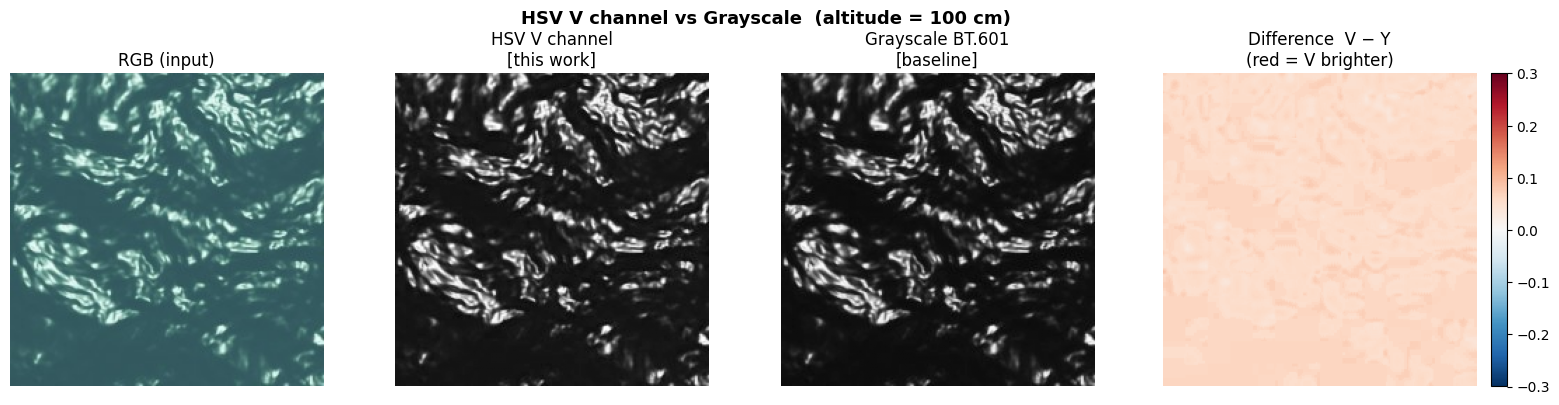

Sample    V mean   GS mean     V max    GS max    V−GS max
----------------------------------------------------------
100_motionblur.jpg    0.4915    0.4332    0.9804    0.9335      0.0828
400_motionblur.jpg    0.4754    0.4179    1.0000    0.9696      0.0839
100_std.jpg    0.4556    0.3975    1.0000    0.9710      0.0897
400_gaussblur.jpg    0.4476    0.3925    0.6941    0.6436      0.0712
400_std.jpg    0.4633    0.4067    1.0000    0.9691      0.0839
100_gaussblur.jpg    0.4447    0.3874    0.8980    0.8553      0.0758

Key observation: V max stays closer to 1.0 (specular glints preserved);
                 GS max is lower because weighted averaging dilutes them.


In [ ]:
img_bgr  = cv2.imread('/content/sample_rgb/100_std.jpg')
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
v_chan   = extract_value_channel(img_rgb)
gs_chan  = grayscale_from_rgb(img_rgb)
diff     = v_chan - gs_chan

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_rgb);               axes[0].set_title("RGB (input)")
axes[1].imshow(v_chan,  cmap="gray");  axes[1].set_title("HSV V channel\n[this work]")
axes[2].imshow(gs_chan, cmap="gray");  axes[2].set_title("Grayscale BT.601\n[baseline]")
im = axes[3].imshow(diff, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[3].set_title("Difference  V − Y\n(red = V brighter)")
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
for ax in axes:
    ax.axis("off")
plt.suptitle(f"HSV V channel vs Grayscale  (altitude = 100 cm)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Quantitative comparison across altitudes ────────────────────────────────────
print(f"{'Sample':>6}  {'V mean':>8}  {'GS mean':>8}  {'V max':>8}  {'GS max':>8}  {'V−GS max':>10}")
print("-" * 58)
for item in os.scandir("/content/sample_rgb/"):
    img = cv2.imread(item.path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    v   = extract_value_channel(img)
    gs  = grayscale_from_rgb(img)
    print(f"{item.name:>4}  {v.mean():>8.4f}  {gs.mean():>8.4f}  "
          f"{v.max():>8.4f}  {gs.max():>8.4f}  {(v - gs).max():>10.4f}")

print("\nKey observation: V max stays closer to 1.0 (specular glints preserved);")
print("                 GS max is lower because weighted averaging dilutes them.")

# 2. Feature Engineering

In [ ]:
PROBE_ALTS = [50, 100, 200, 400, 800]

## 2.1 2D FFT

In [ ]:
# Ported from waternet_v2/data/preprocessing.py
"""
Text section 2.3.2

F(u,v) = Σ_x Σ_y f(x,y) · exp(−j2π(ux/M + vy/N))   [Eq. 2.12]

Energy is partitioned by normalised radial distance r ∈ [0, 1] from DC:
  low  band  (r < 0.20) : large-scale waves / smooth surface → ↑ at high altitude
  mid  band  (0.20–0.60): medium texture
  high band  (r ≥ 0.60) : fine ripples / capillary waves    → ↑ at low altitude
"""


def compute_fft_magnitude(v_channel: np.ndarray) -> np.ndarray:
    """2D FFT log-magnitude spectrum, normalised to [0, 1].

    Args:
        v_channel: Single-channel float32 image in [0, 1].

    Returns:
        Log-magnitude spectrum, float32 in [0, 1], same spatial shape.
    """
    f_shift   = np.fft.fftshift(np.fft.fft2(v_channel))
    magnitude = np.log1p(np.abs(f_shift)).astype(np.float32)
    max_val   = magnitude.max()
    if max_val > 0:
        magnitude /= max_val
    return magnitude

In [ ]:
def compute_fft_energy_bands(
    v_channel: np.ndarray,
    low_cutoff: float = 0.20,
    mid_cutoff: float = 0.60,
) -> tuple:
    """Partition FFT energy into (low, mid, high) radial frequency bands.

    Args:
        v_channel:   Single-channel float32 image in [0, 1].
        low_cutoff:  Normalised radial boundary separating low from mid band.
        mid_cutoff:  Normalised radial boundary separating mid from high band.

    Returns:
        (energy_low, energy_mid, energy_high) — fractions summing to ~1.
    """
    h, w = v_channel.shape
    F    = np.fft.fftshift(np.fft.fft2(v_channel))
    mag  = np.abs(F)

    cy, cx = h // 2, w // 2
    yy, xx = np.mgrid[0:h, 0:w]
    r_norm = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2) / (
        np.sqrt(cy ** 2 + cx ** 2) + 1e-10
    )

    total  = mag.sum() + 1e-10
    e_low  = float(mag[r_norm <  low_cutoff].sum() / total)
    e_mid  = float(mag[(r_norm >= low_cutoff) & (r_norm < mid_cutoff)].sum() / total)
    e_high = float(mag[r_norm >= mid_cutoff].sum() / total)
    return e_low, e_mid, e_high

In [ ]:
# Verify FFT energy shifts with altitude
N_SAMPLES = 8

records = []
print(f"{'Alt (cm)':>10}  {'Low band':>10}  {'Mid band':>10}  {'High band':>10}")
print("-" * 50)
for alt in PROBE_ALTS:
    lows, mids, highs = [], [], []
    for s in range(N_SAMPLES):
        v = extract_value_channel(loadImageFromDataSet(alt))
        l, m, h_e = compute_fft_energy_bands(v)
        lows.append(l); mids.append(m); highs.append(h_e)
    records.append((alt, np.mean(lows), np.mean(mids), np.mean(highs)))
    print(f"{alt:>8} cm  {np.mean(lows):>10.4f}  {np.mean(mids):>10.4f}  {np.mean(highs):>10.4f}")

print("\nExpected: high-band energy INCREASES as altitude INCREASES.")

  Alt (cm)    Low band    Mid band   High band
--------------------------------------------------
      50 cm      0.6996      0.2472      0.0533
     100 cm      0.5417      0.3909      0.0674
     200 cm      0.4983      0.4004      0.1012
     400 cm      0.4057      0.4573      0.1369
     800 cm      0.3425      0.4936      0.1639

Expected: high-band energy INCREASES as altitude INCREASES.


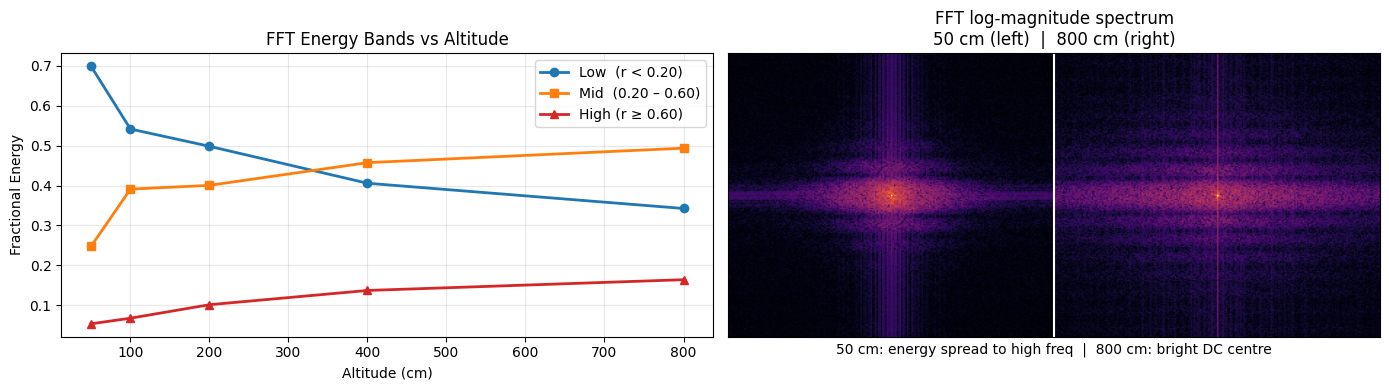

In [ ]:
alts_r  = np.array([r[0] for r in records])
lows_r  = np.array([r[1] for r in records])
mids_r  = np.array([r[2] for r in records])
highs_r = np.array([r[3] for r in records])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(alts_r, lows_r,  "o-", label="Low  (r < 0.20)",   color="#1f77b4", lw=2)
axes[0].plot(alts_r, mids_r,  "s-", label="Mid  (0.20 – 0.60)", color="#ff7f0e", lw=2)
axes[0].plot(alts_r, highs_r, "^-", label="High (r ≥ 0.60)",   color="#d62728", lw=2)
axes[0].set_xlabel("Altitude (cm)"); axes[0].set_ylabel("Fractional Energy")
axes[0].set_title("FFT Energy Bands vs Altitude")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

img_lo  = loadImageFromDataSet(50, motion=1, gauss=0, seed=42)
img_hi  = loadImageFromDataSet(800, motion=1, gauss=0, seed=42)
spec_lo = compute_fft_magnitude(extract_value_channel(img_lo))
spec_hi = compute_fft_magnitude(extract_value_channel(img_hi))
axes[1].imshow(np.hstack([spec_lo, spec_hi]), cmap="inferno", aspect="auto")
axes[1].axvline(x=spec_lo.shape[1] - 0.5, color="white", linewidth=1.5)
axes[1].set_title("FFT log-magnitude spectrum\n"
                  "50 cm (left)  |  800 cm (right)")
axes[1].set_xlabel("50 cm: energy spread to high freq  |  800 cm: bright DC centre")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()

## 2.2 Shi-Tomasi Corner Density

In [ ]:
# Ported from waternet_v2/data/preprocessing.py
"""
Paper Section 2.3.3

Shi-Tomasi criterion: corner if  min(λ₁, λ₂) > τ   [Eq. 2.16]
where λ₁, λ₂ are eigenvalues of the local structure tensor M.

Specular reflection peaks create high-gradient regions that the detector
classifies as "corners".  Their count DECREASES with altitude because
fewer individual wave facets produce resolvable specular reflections.
"""


def count_shi_tomasi_features(
    v_channel: np.ndarray,
    max_corners: int = 100,
    quality_level: float = 0.5,
    min_distance: float = 24.0,
) -> int:
    """Count Shi-Tomasi corners as a proxy for specular glint density.

    Args:
        v_channel:     Single-channel float32 image in [0, 1].
        max_corners:   Maximum corners to detect.
        quality_level: Minimum corner quality (fraction of max eigenvalue).
        min_distance:  Minimum pixel distance between returned corners.

    Returns:
        Integer count of detected corners in [0, max_corners].
    """
    img_u8  = (v_channel * 255).astype(np.uint8)
    corners = cv2.goodFeaturesToTrack(
        img_u8,
        maxCorners=max_corners,
        qualityLevel=quality_level,
        minDistance=min_distance,
    )
    return int(len(corners)) if corners is not None else 0

In [ ]:
# Corner counts vs altitude
N_SAMPLES = 200
corner_means, corner_stds = [], []

print(f"{'Alt (cm)':>10}  {'Mean corners':>14}  {'Std':>8}")
print("-" * 38)
for alt in PROBE_ALTS:
    counts = [
        count_shi_tomasi_features(
            extract_value_channel(loadImageFromDataSet(alt, motion=0, gauss=0, seed=42))
        )
        for s in range(N_SAMPLES)
    ]
    m, s = np.mean(counts), np.std(counts)
    corner_means.append(m); corner_stds.append(s)
    print(f"{alt:>8} cm  {m:>14.1f}  {s:>8.1f}")

print("\nExpected: corner count INCREASES with altitude, but then it reaches a plateau.")

  Alt (cm)    Mean corners       Std
--------------------------------------
      50 cm            14.2       4.3
     100 cm            24.5       8.7
     200 cm            30.2      13.1
     400 cm            33.3      13.1
     800 cm            32.4      14.1

Expected: corner count INCREASES with altitude, but then it reaches a plateau.


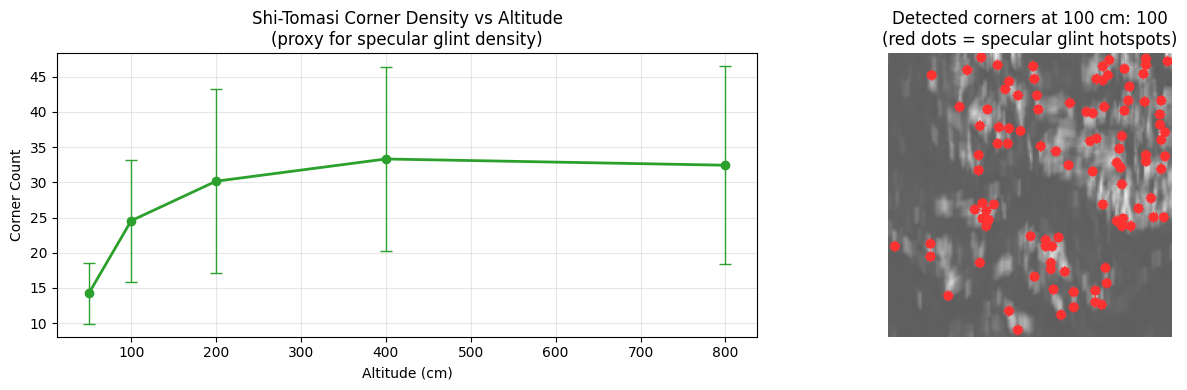

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].errorbar(PROBE_ALTS, corner_means, yerr=corner_stds,
                 fmt="o-", capsize=4, color="#2ca02c", linewidth=2, elinewidth=1)
axes[0].set_xlabel("Altitude (cm)"); axes[0].set_ylabel("Corner Count")
axes[0].set_title("Shi-Tomasi Corner Density vs Altitude\n"
                  "(proxy for specular glint density)")
axes[0].grid(True, alpha=0.3)

demo_img  = loadImageFromDataSet(100, motion=0, gauss=0)
demo_v    = extract_value_channel(demo_img)
demo_u8   = (demo_v * 255).astype(np.uint8)
corners   = cv2.goodFeaturesToTrack(demo_u8, maxCorners=100,
                                    qualityLevel=0.01, minDistance=5)
vis_img   = demo_img.copy()
n_corners = 0
if corners is not None:
    n_corners = len(corners)
    for pt in corners.reshape(-1, 2):
        cv2.circle(vis_img, (int(pt[0]), int(pt[1])), 4, (255, 50, 50), -1)
axes[1].imshow(vis_img)
axes[1].set_title(f"Detected corners at 100 cm: {n_corners}\n"
                  "(red dots = specular glint hotspots)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 2.3 Feature vector

In [ ]:
# Ported from waternet_v2/data/preprocessing.py
"""
The 12-element handcrafted feature vector (Paper Section 2.3):

  Index  Name               Description
  ─────  ─────────────────  ──────────────────────────────────────────────────
  0      mean_v             Mean pixel intensity of the V channel
  1      std_v              Standard deviation of V channel
  2      skew_v             Skewness (asymmetry of intensity distribution)
  3      kurt_v             Kurtosis (tailedness; glints → heavy tail → ↑ kurtosis)
  4      fft_energy_low     FFT energy in r < 0.20 (DC / large-scale)
  5      fft_energy_mid     FFT energy in 0.20 ≤ r < 0.60
  6      fft_energy_high    FFT energy in r ≥ 0.60 (fine ripples)
  7      grad_mean          Mean Sobel gradient magnitude
  8      grad_std           Std of Sobel gradient magnitude
  9      entropy            Normalised image entropy (texture complexity)
  10     shi_tomasi_count   Corner count (glint density proxy)
  11     local_std_mean     Mean of 8×8 block standard deviations
"""

FEATURE_NAMES = [
    "mean_v", "std_v", "skew_v", "kurt_v",
    "fft_energy_low", "fft_energy_mid", "fft_energy_high",
    "grad_mean", "grad_std", "entropy",
    "shi_tomasi_count", "local_std_mean",
]

In [ ]:
def extract_feature_vector(v_channel: np.ndarray) -> np.ndarray:
    """Extract the 12-element handcrafted feature vector from a V channel.

    Args:
        v_channel: Single-channel float32 image in [0, 1], shape (H, W).

    Returns:
        Feature vector, float32 array of length 12.
    """
    flat = v_channel.ravel()

    # ── 0–3: Pixel statistics ───────────────────────────────────────────────
    mean_v = float(flat.mean())
    std_v  = float(flat.std())
    skew_v = float(stats.skew(flat))
    kurt_v = float(stats.kurtosis(flat))

    # ── 4–6: FFT energy bands ───────────────────────────────────────────────
    e_low, e_mid, e_high = compute_fft_energy_bands(v_channel)

    # ── 7–8: Sobel gradient statistics ──────────────────────────────────────
    gx       = cv2.Sobel(v_channel, cv2.CV_64F, 1, 0, ksize=3)
    gy       = cv2.Sobel(v_channel, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag  = np.sqrt(gx ** 2 + gy ** 2)
    grad_mean = float(grad_mag.mean())
    grad_std  = float(grad_mag.std())

    # ── 9: Image entropy ─────────────────────────────────────────────────────
    hist, _ = np.histogram(flat, bins=32, range=(0.0, 1.0), density=True)
    hist   += 1e-10
    entropy = float(-np.sum(hist * np.log2(hist)) / np.log2(32))

    # ── 10: Shi-Tomasi corner count ──────────────────────────────────────────
    shi_count = float(count_shi_tomasi_features(v_channel))

    # ── 11: Mean of 8×8 block standard deviations ───────────────────────────
    h, w  = v_channel.shape
    patch = 8
    local_stds = [
        v_channel[i:i + patch, j:j + patch].std()
        for i in range(0, h - patch, patch)
        for j in range(0, w - patch, patch)
    ]
    local_std_mean = float(np.mean(local_stds)) if local_stds else 0.0

    return np.array(
        [mean_v, std_v, skew_v, kurt_v,
         e_low,  e_mid, e_high,
         grad_mean, grad_std, entropy,
         shi_count, local_std_mean],
        dtype=np.float32,
    )

In [ ]:
# ── Demo: compare feature vectors at 50 cm vs 800 cm ───────────────────────────
feat_50_std  = extract_feature_vector(extract_value_channel(
    loadImageFromDataSet(50, motion=0, gauss=0, seed=42)))
feat_800_std = extract_feature_vector(extract_value_channel(
    loadImageFromDataSet(800, motion=0, gauss=0, seed=42)))
feat_50_motion  = extract_feature_vector(extract_value_channel(
    loadImageFromDataSet(50, motion=1, gauss=0, seed=42)))
feat_800_motion = extract_feature_vector(extract_value_channel(
    loadImageFromDataSet(800, motion=1, gauss=0, seed=42)))
feat_50_gauss  = extract_feature_vector(extract_value_channel(
    loadImageFromDataSet(50, motion=0, gauss=1, seed=42)))
feat_800_gauss = extract_feature_vector(extract_value_channel(
    loadImageFromDataSet(800, motion=0, gauss=1, seed=42)))

directions = {
    "mean_v":          "↑ at high alt",
    "std_v":           "-",
    "skew_v":          "↑ at low alt",
    "kurt_v":          "↑ at low alt",
    "fft_energy_low":  "↑ at low alt",
    "fft_energy_mid":  "↑ at high alt",
    "fft_energy_high": "↑ at high alt",
    "grad_mean":       "↑ at high alt",
    "grad_std":        "↑ at high alt",
    "entropy":         "↑ at high alt",
    "shi_tomasi_count":"↑ at high alt",
    "local_std_mean":  "↑ at high alt",
}

print(f"{'Feature':<22}  {'50 cm':>10}  {'800 cm':>10} {'50 cm motion':>10}  {'800 cm motion':>10} {'50 cm gauss':>10}  {'800 cm gauss':>10} {'Expected trend':>20}")
print("-" * 120)
for name, v50, v800, v50m, v800m, v50g, v800g in zip(FEATURE_NAMES, feat_50_std, feat_800_std, feat_50_motion, feat_800_motion, feat_50_gauss, feat_800_gauss):
    print(f"{name:<22}  {v50:>10.4f}  {v800:>10.4f} {v50m:>10.4f}  {v800m:>10.4f} {v50g:>10.4f}  {v800g:>10.4f} {directions[name]:>20}")

print(f"\nFeature vector shape: {feat_50_std.shape}  (12 elements)")

Feature                      50 cm      800 cm 50 cm motion  800 cm motion 50 cm gauss  800 cm gauss       Expected trend
------------------------------------------------------------------------------------------------------------------------
mean_v                      0.4187      0.5043     0.4330      0.5019     0.4516      0.5058        ↑ at high alt
std_v                       0.0785      0.0845     0.0867      0.0873     0.0790      0.0894                    -
skew_v                      2.4631      0.5055     2.0859      0.6439     1.1235      0.6526         ↑ at low alt
kurt_v                      6.2837     -0.4569     4.4355     -0.3335     0.7425     -0.1790         ↑ at low alt
fft_energy_low              0.6902      0.4562     0.6909      0.4681     0.7081      0.4510         ↑ at low alt
fft_energy_mid              0.2555      0.4472     0.2549      0.4358     0.2305      0.4513        ↑ at high alt
fft_energy_high             0.0543      0.0966     0.0542      0.0961    

# 3 Data pipeline

In [ ]:
# Ported from waternet_v2/data/dataset.py
#
# The dataset is assumed to already exist on disk.
# Expected layout:
#   <image_dir>/          ← folder of JPEG/PNG images
#   <csv_path>            ← CSV with columns: nome, distancia
#
# Configured via cfg["data"]["image_dir"] and cfg["data"]["csv_path"].

import pandas as pd
from pathlib import Path

def load_dataset(
    image_dir: str,
    csv_path: str,
    cfg: dict = None,
) -> pd.DataFrame:
    """Load the dataset CSV and validate that every listed image exists on disk.

    Args:
        image_dir: Folder containing the image files.
        csv_path:  CSV file with columns ``nome`` (filename) and
                   ``distancia`` (altitude in cm).
        cfg:       Optional config dict (used only for ``n_bins_stratify``).

    Returns:
        Validated pd.DataFrame with columns ``nome`` and ``distancia``.

    Raises:
        FileNotFoundError: If the CSV or image directory does not exist.
        ValueError:        If required columns are missing from the CSV.
    """
    image_dir = Path(image_dir)
    csv_path  = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    if not image_dir.is_dir():
        raise FileNotFoundError(f"Image directory not found: {image_dir}")

    df = pd.read_csv(csv_path)

    required = {"nome", "distancia"}
    missing_cols = required - set(df.columns)
    if missing_cols:
        raise ValueError(f"CSV is missing columns: {missing_cols}")

    # ── Cross-check files on disk ──────────────────────────────────────────────
    missing_files = df.loc[
        ~df["nome"].apply(lambda n: (image_dir / n).exists()), "nome"
    ]
    if len(missing_files):
        print(f"WARNING: {len(missing_files)} listed file(s) not found on disk "
              f"(first 5: {missing_files.head().tolist()})")
    else:
        print("File check passed: all listed images found on disk.")

    # ── Statistics ─────────────────────────────────────────────────────────────
    print(f"\nDataset loaded from : {csv_path}")
    print(f"  Total samples  : {len(df):,}")
    print(f"  Altitude range : {df['distancia'].min():.1f} – "
          f"{df['distancia'].max():.1f} cm")
    print(f"  Unique images  : {df['nome'].nunique():,}")
    print(f"  Missing files  : {len(missing_files)} / {len(df)}")

    return df

In [ ]:
cfg = load_config("/content/drive/MyDrive/agua/colab.yaml")
IMAGE_DIR = cfg["data"]["image_dir"]
CSV_PATH  = cfg["data"]["csv_path"]
df = load_dataset(IMAGE_DIR, CSV_PATH, cfg)
df.head()

File check passed: all listed images found on disk.

Dataset loaded from : /content/synth_samples.csv
  Total samples  : 10,517
  Altitude range : 50.0 – 800.0 cm
  Unique images  : 10,517
  Missing files  : 0 / 10517


,nome,distancia,motion,gauss
0,360_vert_0205.jpg,360,1,3
1,360_vert_0218.jpg,360,1,4
2,360_vert_0353.jpg,360,1,4
3,360_vert_0439.jpg,360,1,4
4,360_vert_0430.jpg,360,1,6


## 3.1 Stratification

In [ ]:
# Ported from waternet_v2/data/dataset.py
# No augmentation — WaterDataSequence is used with augmenter=None.

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def make_stratified_split(
    df: pd.DataFrame,
    cfg: dict,
) -> tuple:
    """Produce a stratified 70 / 15 / 15 train / val / test split.

    Stratification bins are computed with ``pd.cut`` on the ``distancia``
    column so that every altitude range is proportionally represented in
    all three splits.

    Args:
        df:  DataFrame with a ``distancia`` column.
        cfg: Config dict; reads ``data.test_size``, ``data.val_size``,
             ``data.n_bins_stratify``, ``project.seed``.

    Returns:
        (df_train, df_val, df_test) — each reset-indexed.
    """
    n_bins    = cfg["data"]["n_bins_stratify"]
    test_size = cfg["data"]["test_size"]
    val_size  = cfg["data"]["val_size"]
    seed      = cfg["project"]["seed"]

    strata = pd.cut(df["distancia"], bins=n_bins, labels=False)

    df_train_val, df_test = train_test_split(
        df, test_size=test_size, random_state=seed, stratify=strata,
    )

    strata_tv = pd.cut(df_train_val["distancia"], bins=n_bins, labels=False)
    df_train, df_val = train_test_split(
        df_train_val, test_size=val_size, random_state=seed, stratify=strata_tv,
    )

    print(f"[Split]  train={len(df_train):,}  val={len(df_val):,}  "
          f"test={len(df_test):,}  total={len(df):,}")
    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )

In [ ]:
class WaterDataSequence(tf.keras.utils.Sequence):
    """Batch generator: image file → HSV V channel → feature vector → batch.

    Per-sample pipeline:
      1. Read RGB image from ``image_dir / nome``.
      2. Resize and extract HSV V channel (V = max(R,G,B)).
      3. Extract the 12-element handcrafted feature vector.
      4. Yield ``{"image_input": V[..., np.newaxis],
                  "feature_input": feat}`` + pre-scaled target.

    Args:
        dataframe:   DataFrame with columns ``nome`` and ``distancia``.
        image_dir:   Folder containing the image files.
        targets:     Pre-scaled target array aligned with ``dataframe``.
        target_size: (width, height) resize target.
        batch_size:  Number of samples per batch.
        shuffle:     Shuffle indices at the end of each epoch.
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        image_dir,
        targets: np.ndarray,
        target_size: tuple = (224, 224),
        batch_size: int = 32,
        shuffle: bool = True,
    ):
        self.df          = dataframe.reset_index(drop=True)
        self.image_dir   = Path(image_dir)
        self.targets     = targets
        self.target_size = target_size
        self.batch_size  = batch_size
        self.shuffle     = shuffle
        self.indices     = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self) -> int:
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, batch_idx: int) -> tuple[dict, np.ndarray]:
        start   = batch_idx * self.batch_size
        end     = min(start + self.batch_size, len(self.df))
        indices = self.indices[start:end]
        batch_imgs: list[np.ndarray] = []
        batch_feats: list[np.ndarray] = []

        for idx in indices:
            img_path = self.image_dir / self.df.loc[idx, "nome"]
            v       = load_and_extract_value_channel(str(img_path), self.target_size)
            feat    = extract_feature_vector(v)
            batch_imgs.append(v[..., np.newaxis])   # shape (H, W, 1)
            batch_feats.append(feat)

        X = {
            "image_input":   np.array(batch_imgs,  dtype=np.float32),
            "feature_input": np.array(batch_feats, dtype=np.float32),
        }
        y = self.targets[indices].astype(np.float32)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# Split
df_train, df_val, df_test = make_stratified_split(df, cfg)

# Scale targets
# StandardScaler is fit only on training targets to prevent leakage.
scaler_y = StandardScaler()
y_train  = scaler_y.fit_transform(df_train[["distancia"]]).ravel()
y_val    = scaler_y.transform(df_val[["distancia"]]).ravel()
y_test   = scaler_y.transform(df_test[["distancia"]]).ravel()

print(f"\nTarget scaler — mean: {scaler_y.mean_[0]:.2f} cm  "
      f"std: {scaler_y.scale_[0]:.2f} cm")

[Split]  train=7,365  val=1,574  test=1,578  total=10,517

Target scaler — mean: 288.13 cm  std: 225.29 cm


In [ ]:
# Instantiate sequences
_size  = tuple(cfg["data"]["image_size"])
_batch = cfg["training"]["batch_size"]

train_seq = WaterDataSequence(df_train, IMAGE_DIR, y_train,
                              target_size=_size, batch_size=_batch, shuffle=True)
val_seq   = WaterDataSequence(df_val,   IMAGE_DIR, y_val,
                              target_size=_size, batch_size=_batch, shuffle=False)
test_seq  = WaterDataSequence(df_test,  IMAGE_DIR, y_test,
                              target_size=_size, batch_size=_batch, shuffle=False)

print(f"Batches — train: {len(train_seq)}  val: {len(val_seq)}  test: {len(test_seq)}")

Batches — train: 231  val: 50  test: 50



Batch shapes:
  image_input   : (32, 224, 224, 1)   (B, H, W, 1)
  feature_input : (32, 12)   (B, 12)
  targets       : (32,)                       (B,)


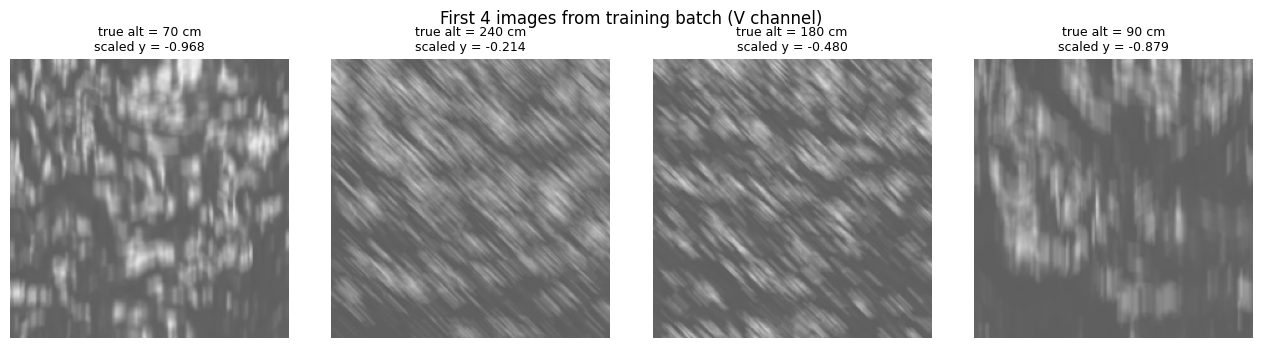

In [ ]:
# Inspect one batch
X_demo, y_demo = train_seq[0]
print(f"\nBatch shapes:")
print(f"  image_input   : {X_demo['image_input'].shape}   (B, H, W, 1)")
print(f"  feature_input : {X_demo['feature_input'].shape}   (B, 12)")
print(f"  targets       : {y_demo.shape}                       (B,)")

# Show a 4-image grid from the first batch
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for i, ax in enumerate(axes):
    ax.imshow(X_demo["image_input"][i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    alt_cm = scaler_y.inverse_transform([[y_demo[i]]])[0, 0]
    ax.set_title(f"true alt = {alt_cm:.0f} cm\n"
                 f"scaled y = {y_demo[i]:.3f}", fontsize=9)
    ax.axis("off")
fig.suptitle("First 4 images from training batch (V channel)", fontsize=12)
plt.tight_layout()
plt.show()

# 4. Models

## 4.1 Linear clamping
Avoid manual bias, improving from the previous version

In [ ]:
# Ported from waternet_v2/models/layers.py and waternet_v2/models/custom_cnn.py

import keras
from keras import layers as KL

class ClampedLinear(KL.Layer):
    """Linear activation with hard clamping to the valid altitude range.

    After the regression head produces an unconstrained float, this layer
    clips it to [min_val, max_val] so predictions never violate physical
    limits (50–800 cm in the normalised domain after inverse-scaling).

    Args:
        min_val: Lower clamp bound (same scale as model output).
        max_val: Upper clamp bound (same scale as model output).
    """

    def __init__(self, min_val: float = 0.0, max_val: float = 1.0, **kwargs):
        super().__init__(**kwargs)
        self.min_val = float(min_val)
        self.max_val = float(max_val)

    def call(self, inputs):
        return tf.clip_by_value(inputs, self.min_val, self.max_val)

    def get_config(self):
        config = super().get_config()
        config.update({"min_val": self.min_val, "max_val": self.max_val})
        return config

## 4.2 Waternet v2

In [ ]:
def build_custom_cnn(
    input_shape: tuple = (224, 224, 1),
    conv_filters=None,
    dense_units=None,
    dropout_rate: float = 0.3,
    apply_physical_constraint: bool = False,
    alt_min_norm: float = 0.0,
    alt_max_norm: float = 1.0,
) -> keras.Model:
    """Build the custom VGG-inspired regression CNN (ablation baseline).

    Architecture:
        Input (224, 224, 1)
        → [Conv2D(f,5×5) → Conv2D(f,5×5) → MaxPool2D] × 4   (conv blocks)
        → GlobalAveragePooling2D
        → Dense(512) → Dropout → Dense(256) → Dropout → Dense(128) → Dropout
        → Dense(1, linear)   [→ ClampedLinear if apply_physical_constraint]

    This model accepts only the image branch (no feature vector input).
    It is the ablation baseline before multi-input fusion is introduced.

    Args:
        input_shape: (H, W, C) — expects (224, 224, 1) for the V channel.
        conv_filters: Filters per convolutional block. Default [32,64,128,256].
        dense_units:  Units in each dense regression layer. Default [512,256,128].
        dropout_rate: Dropout probability applied after deeper layers.
        apply_physical_constraint: If True, clamp output via ClampedLinear.
        alt_min_norm: Lower clamp bound.
        alt_max_norm: Upper clamp bound.

    Returns:
        Uncompiled tf.keras.Model.
    """
    if conv_filters is None:
        conv_filters = [32, 64, 128, 256]
    if dense_units is None:
        dense_units = [512, 256, 128]

    inp = keras.Input(shape=input_shape, name="image_input")
    x   = inp

    for i, n_filters in enumerate(conv_filters):
        x = KL.Conv2D(n_filters, (5, 5), padding="same",
                      activation="relu", name=f"conv_{i}_a")(x)
        x = KL.Conv2D(n_filters, (5, 5), padding="same",
                      activation="relu", name=f"conv_{i}_b")(x)
        x = KL.MaxPool2D(name=f"pool_{i}")(x)
        if i >= 2:
            x = KL.Dropout(dropout_rate, name=f"drop_conv_{i}")(x)

    x = KL.GlobalAveragePooling2D(name="gap")(x)

    for i, units in enumerate(dense_units):
        x = KL.Dense(units, activation="relu", name=f"dense_{i}")(x)
        x = KL.Dropout(dropout_rate, name=f"drop_dense_{i}")(x)

    output = KL.Dense(1, activation="linear", name="output")(x)

    if apply_physical_constraint:
        output = ClampedLinear(
            min_val=alt_min_norm, max_val=alt_max_norm,
            name="physical_constraint",
        )(output)

    return keras.Model(inputs=inp, outputs=output, name="WaterNet_CustomCNN")

In [ ]:
h, w = cfg["data"]["image_size"]
cnn_model = build_custom_cnn(
    input_shape=(h, w, 1),
    apply_physical_constraint=True,
)
cnn_model.summary()

total_p     = cnn_model.count_params()
trainable_p = sum(int(tf.size(w).numpy()) for w in cnn_model.trainable_weights)
print(f"\nTotal parameters     : {total_p:,}")
print(f"Trainable parameters : {trainable_p:,}")
print(f"Input shape          : {cnn_model.input_shape}")
print(f"Output shape         : {cnn_model.output_shape}")

Model: "WaterNet_CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_a (Conv2D)               │ (None, 224, 224, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_b (Conv2D)               │ (None, 224, 224, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_0 (MaxPooling2D)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_a (Conv2D)               │ (None, 112, 112, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_b (Conv2D)               │ (None, 112, 112, 64)   │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_a (Conv2D)               │ (None, 56, 56, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_b (Conv2D)               │ (None, 56, 56, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_conv_2 (Dropout)           │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_a (Conv2D)               │ (None, 28, 28, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_b (Conv2D)               │ (None, 28, 28, 256)    │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_conv_3 (Dropout)           │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense_0 (Dropout)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense_1 (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense_2 (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ physical_constraint             │ (None, 1)              │             0 │
│ (ClampedLinear)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,548,897 (13.54 MB)

 Trainable params: 3,548,897 (13.54 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters     : 3,548,897
Trainable parameters : 3,548,897
Input shape          : (None, 224, 224, 1)
Output shape         : (None, 1)


## 4.3 ResNet50 Transfer Learning

In [ ]:
# Ported from waternet_v2/models/resnet_baseline.py
#
# The key adaptation for single-channel input is channel replication:
# the V channel (H×W×1) is concatenated with itself three times to produce
# a compatible (H×W×3) tensor that matches the ImageNet weight dimensions.
#
# Progressive fine-tuning protocol:
#   Stage 1 — Train only the regression head (frozen backbone).
#   Stage 2 — Unfreeze the last two residual blocks (conv5_x).
#   Stage 3 — Optionally unfreeze conv4_x for deeper adaptation.


def build_resnet50_altitude_model(
    input_shape: tuple = (224, 224, 1),
    head_units=None,
    dropout_rate: float = 0.3,
    freeze_backbone: bool = True,
):
    """Build a ResNet50-based regression model for altitude estimation.

    The V channel is replicated to 3 channels then passed through
    resnet50.preprocess_input (zero-centres with ImageNet statistics)
    before entering the backbone.

    Args:
        input_shape: Model input shape; channel dim must be 1.
        head_units: Dense units in the regression head. Defaults to [256, 128].
        dropout_rate: Dropout applied between Dense layers.
        freeze_backbone: Whether to freeze all backbone layers initially.

    Returns:
        Uncompiled tf.keras.Model.
    """
    if head_units is None:
        head_units = [256, 128]

    # ── Input & channel replication ───────────────────────────────────────── #
    inp = keras.Input(shape=input_shape, name="image_input")
    x = KL.Concatenate(name="channel_replicate")([inp, inp, inp])

    # ── ImageNet pre-processing ───────────────────────────────────────────── #
    x = tf.keras.applications.resnet50.preprocess_input(x)

    # ── Backbone ─────────────────────────────────────────────────────────── #
    backbone = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(input_shape[0], input_shape[1], 3),
    )
    backbone.trainable = not freeze_backbone
    x = backbone(x, training=False)    # BN layers run in inference mode

    # ── Regression head ───────────────────────────────────────────────────── #
    x = KL.GlobalAveragePooling2D(name="gap")(x)
    for i, units in enumerate(head_units):
        x = KL.Dense(units, activation="relu", name=f"dense_{i}")(x)
        x = KL.Dropout(dropout_rate, name=f"drop_{i}")(x)

    output = KL.Dense(1, activation="linear", name="output")(x)

    return keras.Model(inputs=inp, outputs=output, name="WaterNet_ResNet50")

In [ ]:
def unfreeze_top_blocks(
    model,
    n_blocks: int = 1,
    backbone_name: str = "resnet50",
) -> None:
    """Selectively unfreeze the top n_blocks residual blocks in-place.

    ResNet50 block names (from deepest):
        conv5_block3, conv5_block2, conv5_block1  → top block
        conv4_block6, ..., conv4_block1           → second block

    BatchNorm layers are kept in inference mode (trainable=False) to
    preserve running statistics accumulated on ImageNet.

    Args:
        model: The full model returned by build_resnet50_altitude_model.
        n_blocks: Number of residual macro-blocks to unfreeze (1 = conv5_x).
        backbone_name: Name of the ResNet50 sub-model layer.
    """
    backbone = model.get_layer(backbone_name)
    backbone.trainable = True

    # Block prefixes in order from deepest
    block_prefixes = [f"conv{5 - i}" for i in range(n_blocks)]

    for layer in backbone.layers:
        is_in_target_block = any(layer.name.startswith(p) for p in block_prefixes)
        if not is_in_target_block or isinstance(layer, KL.BatchNormalization):
            layer.trainable = False

    print(
        f"[Finetune] Unfrozen blocks: {block_prefixes}  |  "
        f"Trainable params: "
        f"{sum(tf.size(w).numpy() for w in model.trainable_weights):,}"
    )

In [ ]:
def get_finetune_optimizer(
    lr_backbone: float = 1e-5,
    lr_head: float = 1e-4,
    weight_decay: float = 0.01,
):
    """Create an AdamW optimiser for fine-tuning.

    Returns a single AdamW with lr_head; apply this LR when compiling
    the model for Stage 2 / Stage 3.

    Args:
        lr_backbone: Target learning rate for backbone parameters.
        lr_head: Target learning rate for regression head parameters.
        weight_decay: AdamW weight decay coefficient.

    Returns:
        Configured AdamW optimiser instance.
    """
    print(f"[Optimiser] backbone_lr={lr_backbone}  head_lr={lr_head}")
    return keras.optimizers.AdamW(
        learning_rate=lr_head,
        weight_decay=weight_decay,
        clipnorm=1.0,
    )

In [ ]:
# ── Stage 1: frozen backbone — only head trains ────────────────────────────────
h, w = cfg["data"]["image_size"]
resnet_model = build_resnet50_altitude_model(
    input_shape=(h, w, 1),
    freeze_backbone=True,
)
resnet_model.summary()

total_p     = resnet_model.count_params()
trainable_p = sum(int(tf.size(wt).numpy()) for wt in resnet_model.trainable_weights)
print(f"\nTotal parameters     : {total_p:,}")
print(f"Trainable parameters : {trainable_p:,}  (Stage 1 — head only)")
print(f"\nStage 2: call unfreeze_top_blocks(resnet_model, n_blocks=1) to open conv5_x")
print(f"Stage 3: call unfreeze_top_blocks(resnet_model, n_blocks=2) to also open conv4_x")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "WaterNet_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_replicate   │ (None, 224, 224,  │          0 │ image_input[0][0… │
│ (Concatenate)       │ 3)                │            │ image_input[0][0… │
│                     │                   │            │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ channel_replicat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ channel_replicat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ channel_replicat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_0 (Dense)     │ (None, 256)       │    524,544 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_0 (Dropout)    │ (None, 256)       │          0 │ dense_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ drop_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ drop_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total parameters     : 24,145,281
Trainable parameters : 557,569  (Stage 1 — head only)

Stage 2: call unfreeze_top_blocks(resnet_model, n_blocks=1) to open conv5_x
Stage 3: call unfreeze_top_blocks(resnet_model, n_blocks=2) to also open conv4_x


## 4.4 Multi-Input Late-Fusion
Feeding the system with the previous feature engineered tabular data

### 4.4.1 Waternet lite + fusion

In [ ]:
# Ported from waternet_v2/models/multi_input.py
#
# Architecture (late fusion):
#
#   ┌─────────────────────────┐    ┌───────────────────────────┐
#   │  Image branch (CNN)     │    │  Feature branch (MLP)     │
#   │  V channel (H×W×1)      │    │  12-element feature vec   │
#   │  VGG-inspired backbone  │    │  Dense(64) → Dense(32)    │
#   │  → Dense(64) embedding  │    │  embedding                │
#   └────────────┬────────────┘    └──────────────┬────────────┘
#                │                                │
#                └──────── Concatenate ───────────┘
#                                 │
#                           Dense(128) → Dropout → Dense(1)
#
# Fusion strategy: late fusion — each modality is processed through its own
# independent stream and only the high-level representations are merged.


def build_waternet_fusion_lite(
    img_shape: tuple = (224, 224, 1),
    n_features: int = 12,
    conv_filters=None,
    img_embed_units: int = 64,
    feat_dense_units=None,
    fusion_units: int = 128,
    dropout_rate: float = 0.3,
    apply_physical_constraint: bool = False,
    alt_min_norm: float = 0.0,
    alt_max_norm: float = 1.0,
):
    """Build the multi-input late-fusion altitude regression model.

    Args:
        img_shape: Image input shape (H, W, 1).
        n_features: Length of the handcrafted feature vector (default 12).
        conv_filters: Conv block filter counts for the image branch.
            Defaults to [32, 64, 128].
        img_embed_units: Dense units producing the image embedding.
        feat_dense_units: Dense units in the feature branch.
            Defaults to [64, 32].
        fusion_units: Dense units in the merged fusion layer.
        dropout_rate: Dropout probability in the regression head.
        apply_physical_constraint: Clamp output to [alt_min_norm, alt_max_norm].
        alt_min_norm: Lower bound for ClampedLinear.
        alt_max_norm: Upper bound for ClampedLinear.

    Returns:
        Uncompiled tf.keras.Model with inputs ["image_input", "feature_input"].
    """
    if conv_filters is None:
        conv_filters = [32, 64, 128]
    if feat_dense_units is None:
        feat_dense_units = [64, 32]

    # ── Image branch ─────────────────────────────────────────────────────── #
    img_inp = keras.Input(shape=img_shape, name="image_input")
    x = img_inp
    for i, n_filt in enumerate(conv_filters):
        x = KL.Conv2D(n_filt, 3, padding="same", activation="relu",
                      name=f"img_conv{i}_a")(x)
        x = KL.Conv2D(n_filt, 3, padding="same", activation="relu",
                      name=f"img_conv{i}_b")(x)
        x = KL.MaxPool2D(name=f"img_pool{i}")(x)

    x = KL.GlobalAveragePooling2D(name="img_gap")(x)
    x = KL.Dense(img_embed_units, activation="relu", name="img_embedding")(x)

    # ── Feature branch ────────────────────────────────────────────────────── #
    feat_inp = keras.Input(shape=(n_features,), name="feature_input")
    f = feat_inp
    for i, units in enumerate(feat_dense_units):
        f = KL.Dense(units, activation="relu", name=f"feat_dense{i}")(f)

    # ── Late fusion ───────────────────────────────────────────────────────── #
    merged = KL.Concatenate(name="fusion")([x, f])
    z = KL.Dense(fusion_units, activation="relu", name="fusion_dense")(merged)
    z = KL.Dropout(dropout_rate, name="fusion_dropout")(z)
    output = KL.Dense(1, activation="linear", name="output")(z)

    if apply_physical_constraint:
        output = ClampedLinear(
            min_val=alt_min_norm, max_val=alt_max_norm,
            name="physical_constraint",
        )(output)

    return keras.Model(
        inputs=[img_inp, feat_inp],
        outputs=output,
        name="WaterNet_Fusion_lite",
    )

In [ ]:
h, w = cfg["data"]["image_size"]
n_feat = cfg["features"]["n_features"]

multi_model = build_waternet_fusion_lite(
    img_shape=(h, w, 1),
    n_features=n_feat,
)
multi_model.summary()

total_p     = multi_model.count_params()
trainable_p = sum(int(tf.size(wt).numpy()) for wt in multi_model.trainable_weights)
print(f"\nTotal parameters     : {total_p:,}")
print(f"Trainable parameters : {trainable_p:,}")
print(f"Image input shape    : {multi_model.input[0].shape}")
print(f"Feature input shape  : {multi_model.input[1].shape}")
print(f"Output shape         : {multi_model.output.shape}")

Model: "WaterNet_Fusion_lite"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv0_a         │ (None, 224, 224,  │        320 │ image_input[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv0_b         │ (None, 224, 224,  │      9,248 │ img_conv0_a[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_pool0           │ (None, 112, 112,  │          0 │ img_conv0_b[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv1_a         │ (None, 112, 112,  │     18,496 │ img_pool0[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv1_b         │ (None, 112, 112,  │     36,928 │ img_conv1_a[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_pool1           │ (None, 56, 56,    │          0 │ img_conv1_b[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv2_a         │ (None, 56, 56,    │     73,856 │ img_pool1[0][0]   │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv2_b         │ (None, 56, 56,    │    147,584 │ img_conv2_a[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_pool2           │ (None, 28, 28,    │          0 │ img_conv2_b[0][0] │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_gap             │ (None, 128)       │          0 │ img_pool2[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_dense0 (Dense) │ (None, 64)        │        832 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_embedding       │ (None, 64)        │      8,256 │ img_gap[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_dense1 (Dense) │ (None, 32)        │      2,080 │ feat_dense0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 96)        │          0 │ img_embedding[0]… │
│ (Concatenate)       │                   │            │ feat_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 128)       │     12,416 │ fusion[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 310,145 (1.18 MB)

 Trainable params: 310,145 (1.18 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters     : 310,145
Trainable parameters : 310,145
Image input shape    : (None, 224, 224, 1)
Feature input shape  : (None, 12)
Output shape         : (None, 1)


### 4.4.1b Waternet + Fusion

In [ ]:
# Ported from waternet_v2/models/multi_input.py
#
# Architecture (late fusion):
#
#   ┌─────────────────────────┐    ┌───────────────────────────┐
#   │  Image branch (CNN)     │    │  Feature branch (MLP)     │
#   │  V channel (H×W×1)      │    │  12-element feature vec   │
#   │  VGG-inspired backbone  │    │  Dense(64) → Dense(32)    │
#   │  → Dense(512, 256, 128) |    |            embedding      |
#   |              embedding  │    │                           │
#   └────────────┬────────────┘    └──────────────┬────────────┘
#                │                                │
#                └──────── Concatenate ───────────┘
#                                 │
#                           Dense(128) → Dropout → Dense(1)
#
# Fusion strategy: late fusion — each modality is processed through its own
# independent stream and only the high-level representations are merged.
import keras
from keras import layers as KL

def build_waternet_fusion(
    img_shape: tuple = (224, 224, 1),
    n_features: int = 12,
    conv_filters=None,
    img_dense_units = None,
    feat_dense_units:list = [64, 32],
    fusion_units: int = 128,
    dropout_rate: float = 0.3,
    apply_physical_constraint: bool = True,
    alt_min_norm: float = 0.0,
    alt_max_norm: float = 1.0,
):
    """Build the multi-input late-fusion altitude regression model.

    Args:
        img_shape: Image input shape (H, W, 1).
        n_features: Length of the handcrafted feature vector (default 12).
        conv_filters: Conv block filter counts for the image branch.
            Defaults to [32, 64, 128].
        img_embed_units: Dense units producing the image embedding.
        feat_dense_units: Dense units in the feature branch.
            Defaults to [64, 32].
        fusion_units: Dense units in the merged fusion layer.
        dropout_rate: Dropout probability in the regression head.
        apply_physical_constraint: Clamp output to [alt_min_norm, alt_max_norm].
        alt_min_norm: Lower bound for ClampedLinear.
        alt_max_norm: Upper bound for ClampedLinear.

    Returns:
        Uncompiled tf.keras.Model with inputs ["image_input", "feature_input"].
    """
    if conv_filters is None:
        conv_filters = [32, 64, 128, 256]
    if img_dense_units is None:
        img_dense_units = [512, 256, 128]
    if feat_dense_units is None:
        feat_dense_units = [64, 32]

    # ── Image branch ─────────────────────────────────────────────────────── #
    inp = keras.Input(shape=img_shape, name="image_input")
    x   = inp

    for i, n_filters in enumerate(conv_filters):
        x = KL.Conv2D(n_filters, (5, 5), padding="same",
                      activation="relu", name=f"conv_{i}_a")(x)
        x = KL.Conv2D(n_filters, (5, 5), padding="same",
                      activation="relu", name=f"conv_{i}_b")(x)
        x = KL.MaxPool2D(name=f"pool_{i}")(x)
        if i >= 2:
            x = KL.Dropout(dropout_rate, name=f"drop_conv_{i}")(x)

    x = KL.GlobalAveragePooling2D(name="gap")(x)
    for i, units in enumerate(img_dense_units):
        x = KL.Dense(units, activation="relu", name=f"dense_{i}")(x)
        x = KL.Dropout(dropout_rate, name=f"drop_dense_{i}")(x)

    # ── Feature branch ────────────────────────────────────────────────────── #
    feat_inp = keras.Input(shape=(n_features,), name="feature_input")
    f = feat_inp
    for i, units in enumerate(feat_dense_units):
        f = KL.Dense(units, activation="relu", name=f"feat_dense{i}")(f)

    # ── Late fusion ───────────────────────────────────────────────────────── #
    merged = KL.Concatenate(name="fusion")([x, f])
    z = KL.Dense(fusion_units, activation="relu", name="fusion_dense")(merged)
    z = KL.Dropout(dropout_rate, name="fusion_dropout")(z)

    output = KL.Dense(1, activation="linear", name="output")(z)

    if apply_physical_constraint:
        output = ClampedLinear(
            min_val=alt_min_norm, max_val=alt_max_norm,
            name="physical_constraint",
        )(output)

    return keras.Model(
        inputs=[inp, feat_inp],
        outputs=output,
        name="WaterNet_Fusion",
    )

In [ ]:
h, w = cfg["data"]["image_size"]
n_feat = cfg["features"]["n_features"]

waternet_fusion_model = build_waternet_fusion(
    input_shape=(h, w, 1),
    n_features=n_feat,
)
waternet_fusion_model.summary()

total_p     = waternet_fusion_model.count_params()
trainable_p = sum(int(tf.size(wt).numpy()) for wt in waternet_fusion_model.trainable_weights)
print(f"\nTotal parameters     : {total_p:,}")
print(f"Trainable parameters : {trainable_p:,}")
print(f"Image input shape    : {waternet_fusion_model.input[0].shape}")
print(f"Feature input shape  : {waternet_fusion_model.input[1].shape}")
print(f"Output shape         : {waternet_fusion_model.output.shape}")

Model: "WaterNet_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_0_a (Conv2D)   │ (None, 224, 224,  │        832 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_0_b (Conv2D)   │ (None, 224, 224,  │     25,632 │ conv_0_a[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_0              │ (None, 112, 112,  │          0 │ conv_0_b[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_a (Conv2D)   │ (None, 112, 112,  │     51,264 │ pool_0[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_b (Conv2D)   │ (None, 112, 112,  │    102,464 │ conv_1_a[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, 56, 56,    │          0 │ conv_1_b[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2_a (Conv2D)   │ (None, 56, 56,    │    204,928 │ pool_1[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2_b (Conv2D)   │ (None, 56, 56,    │    409,728 │ conv_2_a[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, 28, 28,    │          0 │ conv_2_b[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv_2         │ (None, 28, 28,    │          0 │ pool_2[0][0]      │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3_a (Conv2D)   │ (None, 28, 28,    │    819,456 │ drop_conv_2[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3_b (Conv2D)   │ (None, 28, 28,    │  1,638,656 │ conv_3_a[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 14, 14,    │          0 │ conv_3_b[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv_3         │ (None, 14, 14,    │          0 │ pool_3[0][0]      │
│ (Dropout)           │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 256)       │          0 │ drop_conv_3[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_0 (Dense)     │ (None, 512)       │    131,584 │ gap[0][0]       

 Total params: 3,572,417 (13.63 MB)

 Trainable params: 3,572,417 (13.63 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters     : 3,572,417
Trainable parameters : 3,572,417
Image input shape    : (None, 224, 224, 1)
Feature input shape  : (None, 12)
Output shape         : (None, 1)


### 4.4.2 ResNet50 transfer learning + fusion

In [ ]:
def build_resnet50_multi_input(
    img_shape: tuple = (224, 224, 1),
    n_features: int = 12,
    freeze_backbone: bool = True,
    feat_dense_units=None,
    fusion_units: int = 128,
    dropout_rate: float = 0.3,
):
    """Multi-input model with ResNet50 backbone in the image branch.

    Uses the same channel-replication trick as build_resnet50_altitude_model
    to handle single-channel input.

    Args:
        img_shape: Image input shape (H, W, 1).
        n_features: Handcrafted feature vector length.
        freeze_backbone: Freeze backbone during Stage 1 training.
        feat_dense_units: Dense units in feature branch; defaults to [64, 32].
        fusion_units: Dense units after fusion.
        dropout_rate: Dropout in the head.

    Returns:
        Uncompiled tf.keras.Model.
    """
    if feat_dense_units is None:
        feat_dense_units = [64, 32]

    # ── Image branch (ResNet50) ───────────────────────────────────────────── #
    img_inp = keras.Input(shape=img_shape, name="image_input")
    x = KL.Concatenate(name="channel_replicate")([img_inp, img_inp, img_inp])
    x = tf.keras.applications.resnet50.preprocess_input(x)

    backbone = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(img_shape[0], img_shape[1], 3),
    )
    backbone.trainable = not freeze_backbone
    x = backbone(x, training=False)
    x = KL.GlobalAveragePooling2D(name="img_gap")(x)
    x = KL.Dense(128, activation="relu", name="img_embedding")(x)

    # ── Feature branch ────────────────────────────────────────────────────── #
    feat_inp = keras.Input(shape=(n_features,), name="feature_input")
    f = feat_inp
    for i, units in enumerate(feat_dense_units):
        f = KL.Dense(units, activation="relu", name=f"feat_dense{i}")(f)

    # ── Late fusion ───────────────────────────────────────────────────────── #
    merged = KL.Concatenate(name="fusion")([x, f])
    z = KL.Dense(fusion_units, activation="relu", name="fusion_dense")(merged)
    z = KL.Dropout(dropout_rate, name="fusion_dropout")(z)
    output = KL.Dense(1, activation="linear", name="output")(z)

    return keras.Model(
        inputs=[img_inp, feat_inp],
        outputs=output,
        name="WaterNet_ResNet50_MultiInput",
    )

# 5. Training pipeline

In [ ]:
# Ported from waternet_v2/training/train.py and waternet_v2/training/callbacks.py
#
# Key design decisions:
#   * Target normalisation: StandardScaler is fit on training targets only.
#     The scaler is saved alongside the model for correct inference.
#   * AdamW + Huber loss (δ=1.0): AdamW with weight decay and gradient
#     clipping avoids exploding gradients; Huber combines MSE's smooth
#     gradient near zero with MAE's robustness to outlier altitudes.
#   * ReduceLROnPlateau: halves LR on val_loss plateau.

import json as _json
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler

## 5.1 Callbacks

In [ ]:
class EpochMetricsLogger(keras.callbacks.Callback):
    """Print a concise one-line metrics summary after each epoch."""

    def on_epoch_end(self, epoch: int, logs: dict = None) -> None:
        if not logs:
            return
        parts = [f"Epoch {epoch + 1:03d}"]
        for key, value in logs.items():
            parts.append(f"{key}={value:.4f}")
        print("  ".join(parts))

In [ ]:
class PredictionHistoryCallback(keras.callbacks.Callback):
    """Record full validation predictions at specified epoch intervals.

    Useful for tracking the evolution of systematic bias over training.

    Args:
        val_data: Tuple (X_val, y_val_true) in original scale.
        record_every: Record predictions every this many epochs.
        scaler: Optional sklearn scaler to inverse-transform model output.
    """

    def __init__(self, val_data: tuple, record_every: int = 5,
                 scaler=None) -> None:
        super().__init__()
        self.X_val, self.y_val_true = val_data
        self.record_every = record_every
        self.scaler = scaler
        self.history: dict = {}

    def on_epoch_end(self, epoch: int, logs: dict = None) -> None:
        if (epoch + 1) % self.record_every != 0:
            return
        preds = self.model.predict(self.X_val, verbose=0).ravel()
        if self.scaler is not None:
            preds = self.scaler.inverse_transform(preds.reshape(-1, 1)).ravel()
        self.history[epoch + 1] = preds

In [ ]:
def build_standard_callbacks(
    checkpoint_dir="checkpoints",
    log_dir="logs",
    patience: int = 12,
    lr_factor: float = 0.5,
    lr_patience: int = 5,
    lr_min: float = 1e-7,
    monitor: str = "val_loss",
) -> list:
    """Create the standard callback stack for WaterNet training.

    Includes:
    1. EarlyStopping     — restores best weights after patience stale epochs.
    2. ModelCheckpoint   — saves the best model (by val_loss) to disk.
    3. ReduceLROnPlateau — halves LR on val_loss plateau.
    4. TensorBoard       — logs scalars and weight histograms.
    5. EpochMetricsLogger — concise per-epoch console summary.

    Args:
        checkpoint_dir: Directory for model checkpoints.
        log_dir: Directory for TensorBoard event files.
        patience: EarlyStopping patience in epochs.
        lr_factor: Multiplicative LR reduction factor.
        lr_patience: Epochs of no improvement before LR reduction.
        lr_min: Minimum allowable learning rate.
        monitor: Metric to monitor for EarlyStopping and Checkpoint.

    Returns:
        List of Keras callback instances.
    """
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    Path(log_dir).mkdir(parents=True, exist_ok=True)

    early_stop = keras.callbacks.EarlyStopping(
        monitor=monitor,
        patience=patience,
        restore_best_weights=True,
        verbose=1,
    )
    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(
            Path(checkpoint_dir) / "model_{epoch:02d}_valloss{val_loss:.4f}.keras"
        ),
        monitor=monitor,
        save_best_only=True,
        verbose=1,
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=lr_factor,
        patience=lr_patience,
        min_lr=lr_min,
        verbose=1,
    )
    tensorboard = keras.callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=1,
        write_graph=True,
        update_freq="epoch",
    )

    csv_logger = keras.callbacks.CSVLogger(
        filename=str(log_dir / 'training_log.csv'),
        append=True,
        separator=';'
    )

    return [early_stop, checkpoint, reduce_lr, tensorboard, EpochMetricsLogger(), csv_logger]

## 5.2 Compiler helpers

In [ ]:
def compile_model(
    model,
    learning_rate: float = 1e-3,
    weight_decay: float = 0.01,
    clip_norm: float = 1.0,
    huber_delta: float = 1.0,
) -> None:
    """Compile model in-place with AdamW + Huber loss + RMSE/MAE metrics.

    Args:
        model: Uncompiled Keras model.
        learning_rate: Initial learning rate.
        weight_decay: AdamW weight decay coefficient.
        clip_norm: Gradient clipping norm.
        huber_delta: Huber loss transition point.
    """
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            clipnorm=clip_norm,
        ),
        loss=keras.losses.Huber(delta=huber_delta),
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae"),
        ],
    )
    print(f"[Compile] lr={learning_rate}  weight_decay={weight_decay}  "
          f"huber_delta={huber_delta}")
    print(f"[Compile] Trainable params: "
          f"{sum(tf.size(w).numpy() for w in model.trainable_weights):,}")

In [ ]:
def precompute_features(df, image_dir, target_size=(224, 224), verbose=True):
    """Pre-extract V channel images and feature vectors for an entire split.

    Returns arrays suitable for direct NumPy / LightGBM training, avoiding
    the per-batch overhead of on-the-fly feature extraction.

    Args:
        df: DataFrame with columns 'nome' and 'distancia'.
        image_dir: Directory containing image files.
        target_size: (width, height) resize target.
        verbose: Print progress every 1000 samples.

    Returns:
        (images, features) where:
        - images   shape (N, H, W, 1), float32
        - features shape (N, 12),      float32
    """
    image_dir = Path(image_dir)
    images_list = []
    features_list = []

    for i, row in df.iterrows():
        if verbose and i % 1000 == 0:
            print(f"  Extracting features: {i}/{len(df)}", end="\r")
        img = cv2.imread(str(image_dir / row["nome"]))
        v = extract_value_channel(img, target_size)
        images_list.append(v[..., np.newaxis])
        features_list.append(extract_feature_vector(v))

    if verbose:
        print(f"  Feature extraction complete: {len(df)} samples.")

    return (np.array(images_list, dtype=np.float32),
            np.array(features_list, dtype=np.float32))

### 5.3.1 Full training pipeline

In [ ]:
def run_training_pipeline(
    model_type: str = "waternet",
    config_path=None,
    output_dir="outputs",
    seed: int = 42,
) -> dict:
    """Run the complete WaterNet v2 training pipeline.

    Steps:
    1. Load config and set seeds.
    2. Load CSV and perform stratified 70/15/15 split.
    3. Fit StandardScaler on training targets.
    4. Pre-extract images + feature vectors for all splits.
    5. Build and compile model.
    6. Train with standard callbacks.
    7. Save model, scaler, and training history.

    Args:
        model_type: One of "custom_cnn", "resnet50", "multi_input".
        config_path: Optional path to override config YAML.
        output_dir: Directory to save model artefacts.
        seed: Global random seed.

    Returns:
        Dictionary with keys: model, history, scaler_y, splits, config.
    """
    import random
    import os as _os
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    _os.environ["PYTHONHASHSEED"] = str(seed)

    _cfg = load_config(config_path)
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    data_cfg  = _cfg["data"]
    train_cfg = _cfg["training"]
    img_size  = tuple(data_cfg["image_size"])   # (H, W)
    target_size_wh = (img_size[1], img_size[0]) # OpenCV uses (W, H)

    print(f"[Pipeline] Model type : {model_type}")
    print(f"[Pipeline] Image size : {img_size}")
    print(f"[Pipeline] Output dir : {out_dir}")

    # ── Load data ─────────────────────────────────────────────────────────── #
    import pandas as _pd
    df = _pd.read_csv(data_cfg["csv_path"])
    print(f"[Pipeline] Dataset loaded: {len(df):,} rows")

    df_train, df_val, df_test = make_stratified_split(df, _cfg)

    # ── Target normalisation ──────────────────────────────────────────────── #
    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(
        df_train[["distancia"]].values
    ).ravel().astype(np.float32)
    y_val = scaler_y.transform(
        df_val[["distancia"]].values
    ).ravel().astype(np.float32)

    print(f"[Scaler]   mean={scaler_y.mean_[0]:.1f} cm  "
          f"std={scaler_y.scale_[0]:.1f} cm")

    # ── Build model ───────────────────────────────────────────────────────── #
    h, w = img_size
    if model_type == "waternet":
        _model = build_custom_cnn(input_shape=(h, w, 1))
    elif model_type == "resnet50":
        _model = build_resnet50_altitude_model(input_shape=(h, w, 1))
    elif model_type == "waternet_fusion":
        _model = build_waternet_fusion(
            img_shape=(h, w, 1),
            n_features=_cfg["features"]["n_features"],
        )
    elif model_type == "waternet_fusion_lite":
        _model = build_waternet_fusion_lite(
            img_shape=(h, w, 1),
            n_features=_cfg["features"]["n_features"],
    )
    elif model_type == "resnet50_fusion":
        _model = build_resnet50_multi_input(
            img_shape=(h, w, 1),
            n_features=_cfg["features"]["n_features"],
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type!r}")

    _model.summary(print_fn=print)

    compile_model(
        _model,
        learning_rate=train_cfg["learning_rate"],
        weight_decay=train_cfg["weight_decay"],
        clip_norm=train_cfg["clip_norm"],
        huber_delta=train_cfg["huber_delta"],
    )

    # ── Data generators ───────────────────────────────────────────────────── #
    image_dir  = data_cfg["image_dir"]

    train_gen = WaterDataSequence(
        df_train, image_dir, y_train,
        target_size=target_size_wh,
        batch_size=train_cfg["batch_size"],
    )
    val_gen = WaterDataSequence(
        df_val, image_dir, y_val,
        target_size=target_size_wh,
        batch_size=train_cfg["batch_size"],
        shuffle=False,
    )

    # ── Train ─────────────────────────────────────────────────────────────── #
    cbs = build_standard_callbacks(
        checkpoint_dir=out_dir / "checkpoints",
        log_dir=out_dir / "logs",
        patience=train_cfg["patience"],
        lr_factor=train_cfg["lr_factor"],
        lr_patience=train_cfg["lr_patience"],
        lr_min=train_cfg["lr_min"],
    )

    history = _model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=train_cfg["epochs"],
        callbacks=cbs,
        verbose=1,
    )

    # ── Persist artefacts ─────────────────────────────────────────────────── #
    _model.save(out_dir / "waternet_v2_final.keras")

    with open(out_dir / "scaler_y.pkl", "wb") as fh:
        pickle.dump(scaler_y, fh)

    scaler_meta = {
        "mean": float(scaler_y.mean_[0]),
        "scale": float(scaler_y.scale_[0]),
    }
    with open(out_dir / "scaler_y.json", "w") as fh:
        _json.dump(scaler_meta, fh, indent=2)

    history_dict = {k: [float(v) for v in vals]
                    for k, vals in history.history.items()}
    with open(out_dir / "training_history.json", "w") as fh:
        _json.dump(history_dict, fh, indent=2)

    print(f"\n[Pipeline] Artefacts saved to: {out_dir}")

    return {
        "model":    _model,
        "history":  history.history,
        "scaler_y": scaler_y,
        "splits":   {"train": df_train, "val": df_val, "test": df_test},
        "config":   _cfg,
    }

To train, set image_dir and csv_path in the .yaml,
then call:

```
  results = run_training_pipeline(
      model_type="multi_input",   # "custom_cnn" | "resnet50" | "multi_input"
      output_dir="outputs/run_01",
  )
  model   = results['model']
  history = results['history']
  scaler  = results['scaler_y']
```

Saved artefacts:
- outputs/run_01/waternet_v2_final.keras  — best model weights
- outputs/run_01/scaler_y.json            — target scaler parameters
- outputs/run_01/training_history.json    — epoch-by-epoch metrics

# 6. Training

## 6.1 Waternet

### 6.1.1 Waternet v2 (no-fusion) [DONE]

In [ ]:
waternet_v2_results = run_training_pipeline(
    model_type="waternet",   # "waternet" | "resnet50" | "waternet_fusion" | "resnet50_fusion"
    output_dir="/content/drive/MyDrive/agua/v2/watenet/run_01",
    config_path="/content/drive/MyDrive/agua/colab_128.yaml"
)

[Pipeline] Model type : waternet
[Pipeline] Image size : (224, 224)
[Pipeline] Output dir : /content/drive/MyDrive/agua/v2/watenet/run_01
[Pipeline] Dataset loaded: 10,517 rows
[Split]  train=7,365  val=1,574  test=1,578  total=10,517
[Scaler]   mean=288.1 cm  std=225.3 cm


Model: "WaterNet_CustomCNN"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_a (Conv2D)               │ (None, 224, 224, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0_b (Conv2D)               │ (None, 224, 224, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_0 (MaxPooling2D)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_a (Conv2D)               │ (None, 112, 112, 64)   │        51,264 │
├─────────────────────────────────┼─────────────

### 6.1.2 Waternet v2 (fusion lite) [DONE]

In [ ]:
waternet_fusion_results = run_training_pipeline(
    model_type="waternet_fusion_lite",   # "waternet" | "resnet50" | "waternet_fusion" | "resnet50_fusion"
    output_dir="/content/drive/MyDrive/agua/v2/waternet_fusion/run_lite",
    config_path="/content/drive/MyDrive/agua/colab_128.yaml"
)

[Pipeline] Model type : waternet_fusion_lite
[Pipeline] Image size : (224, 224)
[Pipeline] Output dir : /content/drive/MyDrive/agua/v2/waternet_fusion/run_lite
[Pipeline] Dataset loaded: 10,517 rows
[Split]  train=7,365  val=1,574  test=1,578  total=10,517
[Scaler]   mean=288.1 cm  std=225.3 cm


Model: "WaterNet_Fusion_lite"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv0_a         │ (None, 224, 224,  │        320 │ image_input[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_conv0_b         │ (None, 224, 224,  │      9,248 │ img_conv0_a[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_pool0           │ (None, 112, 112,  │   

### 6.1.3 Waternet v2 (fusion-full)

In [ ]:
waternet_fusion_full_results = run_training_pipeline(
    model_type="waternet_fusion",   # "waternet" | "resnet50" | "waternet_fusion" | "resnet50_fusion"
    output_dir="/content/drive/MyDrive/agua/v2/waternet_fusion/run_full",
    config_path="/content/drive/MyDrive/agua/colab_128.yaml"
)

[Pipeline] Model type : waternet_fusion
[Pipeline] Image size : (224, 224)
[Pipeline] Output dir : /content/drive/MyDrive/agua/v2/waternet_fusion/run_full
[Pipeline] Dataset loaded: 10,517 rows
[Split]  train=7,365  val=1,574  test=1,578  total=10,517
[Scaler]   mean=288.1 cm  std=225.3 cm


Model: "WaterNet_Fusion"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_0_a (Conv2D)   │ (None, 224, 224,  │        832 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_0_b (Conv2D)   │ (None, 224, 224,  │     25,632 │ conv_0_a[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_0              │ (None, 112, 112,  │        

## 6.2 ResNet50

### 6.2.1 ResNet50 (no-fusion)

In [ ]:
resnet50_results = run_training_pipeline(
    model_type="resnet50",   # "waternet" | "resnet50" | "waternet_fusion" | "resnet50_fusion"
    output_dir="/content/drive/MyDrive/agua/v2/resnet50/run_01",
    config_path="/content/drive/MyDrive/agua/colab_128.yaml"
)

[Pipeline] Model type : resnet50
[Pipeline] Image size : (224, 224)
[Pipeline] Output dir : /content/drive/MyDrive/agua/v2/resnet50/run_01
[Pipeline] Dataset loaded: 10,517 rows
[Split]  train=7,365  val=1,574  test=1,578  total=10,517
[Scaler]   mean=288.1 cm  std=225.3 cm


Model: "WaterNet_ResNet50"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_replicate   │ (None, 224, 224,  │          0 │ image_input[0][0… │
│ (Concatenate)       │ 3)                │            │ image_input[0][0… │
│                     │                   │            │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ channel_replicat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼──────

### 6.2.2 ResNet50 (fusion)

In [ ]:
resnet50_fusion_results = run_training_pipeline(
    model_type="resnet50_fusion",   # "waternet" | "resnet50" | "waternet_fusion" | "resnet50_fusion"
    output_dir="/content/drive/MyDrive/agua/v2/resnet50/run_fusion",
    config_path="/content/drive/MyDrive/agua/colab_128.yaml"
)

[Pipeline] Model type : resnet50_fusion
[Pipeline] Image size : (224, 224)
[Pipeline] Output dir : /content/drive/MyDrive/agua/v2/resnet50/run_fusion
[Pipeline] Dataset loaded: 10,517 rows
[Split]  train=7,365  val=1,574  test=1,578  total=10,517
[Scaler]   mean=288.1 cm  std=225.3 cm


Model: "WaterNet_ResNet50_MultiInput"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_replicate   │ (None, 224, 224,  │          0 │ image_input[0][0… │
│ (Concatenate)       │ 3)                │            │ image_input[0][0… │
│                     │                   │            │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ channel_replicat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────

# 7. Calibration

## 7.1 Spline bias

In [ ]:
# Ported from waternet_v2/evaluation/calibration.py
#
# Problem context:
#   The CNN exhibits non-linear systematic bias — it underestimates low
#   altitudes (where dense specular reflections saturate the model) and
#   overestimates intermediate heights.  A spline fitted on the validation
#   set creates a monotonic mapping (pred → calibrated_pred) that absorbs
#   this bias without retraining.
#
# Algorithm:
#   1. Bin validation predictions into 30 equal-width windows.
#   2. For each bin with ≥ 10 samples compute (mean_pred, mean_true).
#   3. Fit a cubic UnivariateSpline through (mean_pred → mean_true).
#   4. Apply spline to test predictions; clip to [alt_min, alt_max].

from scipy.interpolate import UnivariateSpline

class SplineCalibrator:
    """Cubic-spline post-training bias calibrator.

    Args:
        n_bins: Number of equal-width bins for computing bin-mean statistics.
        min_bin_samples: Minimum samples per bin required to include that
            bin in the spline fitting.
        smoothing: UnivariateSpline smoothing factor (relative to N).
        alt_min_cm: Physical lower altitude bound (50 cm).
        alt_max_cm: Physical upper altitude bound (800 cm).
    """

    def __init__(
        self,
        n_bins: int = 30,
        min_bin_samples: int = 10,
        smoothing: float = 0.1,
        alt_min_cm: float = 50.0,
        alt_max_cm: float = 800.0,
    ) -> None:
        self.n_bins = n_bins
        self.min_bin_samples = min_bin_samples
        self.smoothing = smoothing
        self.alt_min_cm = alt_min_cm
        self.alt_max_cm = alt_max_cm
        self._spline = None
        self._fit_pred = None
        self._fit_true = None

    def fit(self, val_pred: np.ndarray, val_true: np.ndarray) -> "SplineCalibrator":
        """Fit calibration spline on validation set predictions.

        Args:
            val_pred: Model predictions (cm) on the validation set.
            val_true: Ground-truth altitudes (cm) on the validation set.

        Returns:
            Self (for method chaining).
        """
        val_pred = np.asarray(val_pred, dtype=np.float64).ravel()
        val_true = np.asarray(val_true, dtype=np.float64).ravel()

        bins = np.linspace(val_pred.min(), val_pred.max(), self.n_bins + 1)
        bin_preds = []
        bin_trues = []

        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (val_pred >= lo) & (val_pred < hi)
            if mask.sum() >= self.min_bin_samples:
                bin_preds.append(float(val_pred[mask].mean()))
                bin_trues.append(float(val_true[mask].mean()))

        if len(bin_preds) < 4:
            raise RuntimeError(
                f"Not enough bins with ≥{self.min_bin_samples} samples to fit spline "
                f"(got {len(bin_preds)}).  Try reducing min_bin_samples or n_bins."
            )

        self._fit_pred = np.array(bin_preds)
        self._fit_true = np.array(bin_trues)

        self._spline = UnivariateSpline(
            self._fit_pred,
            self._fit_true,
            s=self.smoothing * len(self._fit_pred),
            k=3,
            ext=3,  # extrapolate as boundary value (no wild swings)
        )

        print(f"[Calibration] Spline fitted on {len(bin_preds)} bins  "
              f"(min_samples={self.min_bin_samples})")
        return self

    def transform(self, y_pred: np.ndarray) -> np.ndarray:
        """Apply spline calibration and clip to physical altitude range.

        Args:
            y_pred: Raw model predictions in cm.

        Returns:
            Calibrated predictions clipped to [alt_min_cm, alt_max_cm].
        """
        if self._spline is None:
            raise RuntimeError("Call fit() before transform().")
        calibrated = self._spline(np.asarray(y_pred, dtype=np.float64).ravel())
        return np.clip(calibrated, self.alt_min_cm, self.alt_max_cm).astype(np.float32)

    def fit_transform(self, val_pred: np.ndarray,
                      val_true: np.ndarray) -> np.ndarray:
        """Fit on validation data and return calibrated validation predictions."""
        self.fit(val_pred, val_true)
        return self.transform(val_pred)

    def save(self, path) -> None:
        """Save the calibration control points to a JSON file."""
        if self._fit_pred is None:
            raise RuntimeError("Nothing to save; call fit() first.")
        data = {
            "fit_pred": self._fit_pred.tolist(),
            "fit_true": self._fit_true.tolist(),
            "n_bins": self.n_bins,
            "min_bin_samples": self.min_bin_samples,
            "smoothing": self.smoothing,
            "alt_min_cm": self.alt_min_cm,
            "alt_max_cm": self.alt_max_cm,
        }
        import json as _j
        with open(path, "w") as fh:
            _j.dump(data, fh, indent=2)
        print(f"[Calibration] Control points saved to {path}")

    @classmethod
    def load(cls, path) -> "SplineCalibrator":
        """Reconstruct a calibrator from a previously saved JSON file."""
        import json as _j
        with open(path) as fh:
            data = _j.load(fh)
        obj = cls(
            n_bins=data["n_bins"],
            min_bin_samples=data["min_bin_samples"],
            smoothing=data["smoothing"],
            alt_min_cm=data["alt_min_cm"],
            alt_max_cm=data["alt_max_cm"],
        )
        obj._fit_pred = np.array(data["fit_pred"])
        obj._fit_true = np.array(data["fit_true"])
        obj._spline = UnivariateSpline(
            obj._fit_pred,
            obj._fit_true,
            s=obj.smoothing * len(obj._fit_pred),
            k=3,
            ext=3,
        )
        print(f"[Calibration] Loaded from {path}")
        return obj

[Calibration] Spline fitted on 19 bins  (min_samples=5)


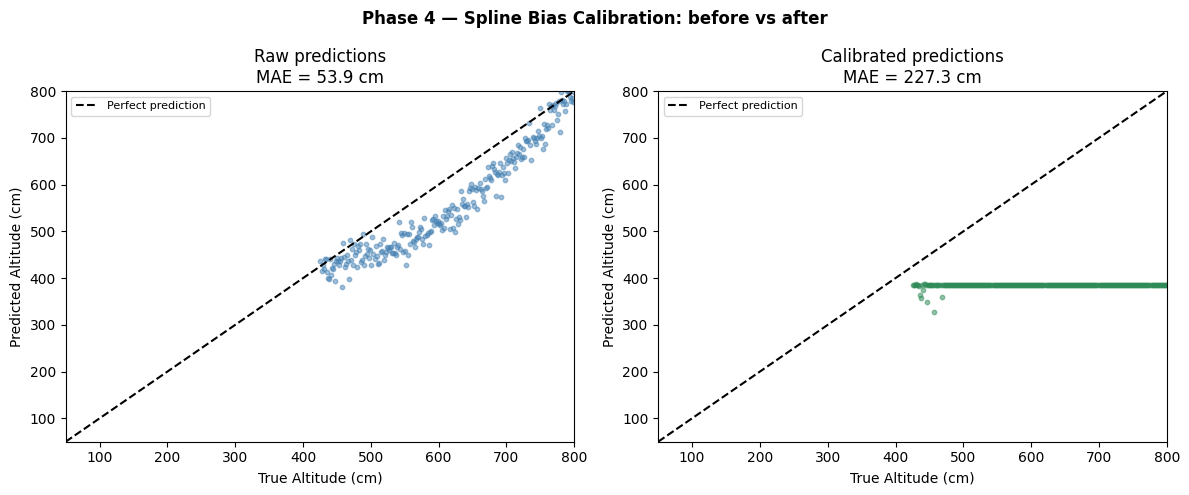


Key observation: the S-curve systematic bias is absorbed by the spline.
The calibrated scatter aligns much more closely with the identity line.


In [ ]:
# ── Demo: S-curve bias before/after calibration ───────────────────────────────
rng_cal = np.random.RandomState(0)
_n = 500
y_true_demo  = np.linspace(50, 800, _n)
# Simulate an S-curve systematic bias: under-predict low, over-predict mid
_noise = rng_cal.normal(0, 20, _n)
y_pred_raw   = (y_true_demo
                + 80 * np.sin(2 * np.pi * (y_true_demo - 50) / 750)
                + _noise)
y_pred_raw   = np.clip(y_pred_raw, 50, 800)

# Split into val (fit spline) and test (apply)
_split = _n // 2
val_true, val_pred   = y_true_demo[:_split], y_pred_raw[:_split]
test_true, test_pred = y_true_demo[_split:], y_pred_raw[_split:]

calibrator = SplineCalibrator(n_bins=20, min_bin_samples=5)
calibrator.fit(val_pred, val_true)
test_pred_cal = calibrator.transform(test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, label, colour in [
    (axes[0], test_pred,     "Raw predictions",        "steelblue"),
    (axes[1], test_pred_cal, "Calibrated predictions", "seagreen"),
]:
    ax.scatter(test_true, pred, s=10, alpha=0.5, color=colour)
    ax.plot([50, 800], [50, 800], "k--", lw=1.5, label="Perfect prediction")
    mae = np.mean(np.abs(pred - test_true))
    ax.set_title(f"{label}\nMAE = {mae:.1f} cm")
    ax.set_xlabel("True Altitude (cm)")
    ax.set_ylabel("Predicted Altitude (cm)")
    ax.set_xlim(50, 800); ax.set_ylim(50, 800)
    ax.legend(fontsize=8)

fig.suptitle("Phase 4 — Spline Bias Calibration: before vs after",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nKey observation: the S-curve systematic bias is absorbed by the spline.")
print("The calibrated scatter aligns much more closely with the identity line.")

In [ ]:
# ── Cell 16: Phase 5 — Full Metrics Suite ─────────────────────────────────────
# Ported from waternet_v2/evaluation/metrics.py
#
# Metric selection rationale:
#   MAE    — robust to outliers; optimal for Laplacian-distributed errors.
#   RMSE   — penalises large errors quadratically; preferred for
#             safety-critical altitude where large errors are dangerous.
#   MedAE  — outlier-robust central tendency.
#   R²     — fraction of variance explained; 1 = perfect, 0 = mean baseline.
#   MAPE   — scale-independent; a 10 cm error at 50 cm (20%) is more
#             operationally significant than the same error at 500 cm (2%).
#   AbsRel — absolute relative error; the Eigen et al. depth metric.
#   δ<1.25 — fraction of predictions within 25% of ground truth.

import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)

def compute_full_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Compute the full regression metrics suite.

    Args:
        y_true: Ground-truth altitudes in cm, shape (N,).
        y_pred: Predicted altitudes in cm, shape (N,).

    Returns:
        Ordered dictionary of metric name → float value.
    """
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()

    errors     = y_true - y_pred
    abs_errors = np.abs(errors)
    ratio      = np.maximum(y_pred / (y_true + 1e-8), y_true / (y_pred + 1e-8))

    return {
        "MAE (cm)":       float(mean_absolute_error(y_true, y_pred)),
        "RMSE (cm)":      float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MedAE (cm)":     float(median_absolute_error(y_true, y_pred)),
        "R²":             float(r2_score(y_true, y_pred)),
        "MAPE (%)":       float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        "Max Error (cm)": float(abs_errors.max()),
        "Error Std (cm)": float(errors.std()),
        "AbsRel":         float(np.mean(abs_errors / (y_true + 1e-8))),
        "δ<1.25 (%)":     float((ratio < 1.25).mean() * 100),
        "δ<1.25² (%)":    float((ratio < 1.5625).mean() * 100),
    }


def print_metrics(metrics: dict, title: str = "Metrics") -> None:
    """Pretty-print a metrics dictionary to stdout.

    Args:
        metrics: Output of compute_full_metrics.
        title: Section header string.
    """
    width = 28
    print(f"\n{'─' * (width + 14)}")
    print(f"  {title}")
    print(f"{'─' * (width + 14)}")
    for name, value in metrics.items():
        print(f"  {name:<{width}} {value:>8.4f}")
    print(f"{'─' * (width + 14)}\n")


def evaluate_by_altitude_range(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    bins=None,
) -> pd.DataFrame:
    """Compute metrics stratified by altitude range.

    Reveals where the model fails (e.g., systematic underestimation at
    low altitudes where specular reflections are most dense).

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        bins: Altitude bin edges in cm. Defaults to
            [50, 100, 200, 300, 400, 500, 600, 700, 800].

    Returns:
        DataFrame with one row per altitude range and columns:
        range, n_samples, mae, rmse, mape, median_error, p95_error, r2.
    """
    if bins is None:
        bins = [50, 100, 200, 300, 400, 500, 600, 700, 800]

    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()

    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_true >= lo) & (y_true < hi)
        if not mask.any():
            continue
        yt, yp = y_true[mask], y_pred[mask]
        abs_err = np.abs(yt - yp)
        rows.append({
            "range (cm)": f"{lo}–{hi}",
            "n_samples":  int(mask.sum()),
            "MAE":        float(mean_absolute_error(yt, yp)),
            "RMSE":       float(np.sqrt(mean_squared_error(yt, yp))),
            "MAPE (%)":   float(mean_absolute_percentage_error(yt, yp) * 100),
            "MedAE":      float(np.median(abs_err)),
            "P95 Error":  float(np.percentile(abs_err, 95)),
            "R²":         float(r2_score(yt, yp)),
        })

    return pd.DataFrame(rows)


def build_comparison_table(results: dict) -> pd.DataFrame:
    """Build an ablation study comparison table.

    Args:
        results: Dictionary mapping model name → (y_true, y_pred) tuples.

    Returns:
        DataFrame with one row per model and key metric columns,
        sorted by RMSE.
    """
    rows = []
    for model_name, (y_true, y_pred) in results.items():
        m = compute_full_metrics(y_true, y_pred)
        rows.append({
            "Model":      model_name,
            "MAE (cm)":   m["MAE (cm)"],
            "RMSE (cm)":  m["RMSE (cm)"],
            "R²":         m["R²"],
            "MAPE (%)":   m["MAPE (%)"],
            "δ<1.25 (%)": m["δ<1.25 (%)"],
        })
    return pd.DataFrame(rows).sort_values("RMSE (cm)").reset_index(drop=True)


# ── Demo: metrics on synthetic predictions ────────────────────────────────────
rng_m = np.random.RandomState(1)
_n_eval = 400

# Simulate ground truth uniformly across the altitude range
y_true_eval = rng_m.uniform(50, 800, _n_eval).astype(np.float32)

# Three hypothetical model predictions with different quality levels
y_pred_mean   = np.full_like(y_true_eval, y_true_eval.mean())          # mean baseline
y_pred_noisy  = y_true_eval + rng_m.normal(0, 80, _n_eval)             # noisy CNN
y_pred_good   = y_true_eval + rng_m.normal(0, 30, _n_eval)             # better model
y_pred_good   = np.clip(y_pred_good, 50, 800)
y_pred_noisy  = np.clip(y_pred_noisy, 50, 800)

# Full metrics on the better model
m = compute_full_metrics(y_true_eval, y_pred_good)
print_metrics(m, title="Synthetic 'Good Model' — Test Set")

# Stratified evaluation
strat = evaluate_by_altitude_range(y_true_eval, y_pred_good)
print("Stratified metrics by altitude range:")
print(strat.to_string(index=False))

# Ablation comparison table
comparison = build_comparison_table({
    "Mean Baseline": (y_true_eval, y_pred_mean),
    "Noisy CNN":     (y_true_eval, y_pred_noisy),
    "Good Model":    (y_true_eval, y_pred_good),
    "Calibrated":    (y_true_eval, test_pred_cal),   # from Cell 15
})
print("\nAblation comparison table:")
print(comparison.to_string(index=False))
print("\nKey observation: MAPE is disproportionately high at 50–100 cm even")
print("when absolute error is similar across ranges — altitude scale effect.")

In [ ]:
# ── Cell 17: Phase 5 — Publication Visualisations ─────────────────────────────
# Ported from waternet_v2/evaluation/visualization.py
#
# Seven plot types required by the paper:
#   1. Training curves       — loss + RMSE per epoch (train + val)
#   2. Scatter plot          — predictions vs ground truth with identity line
#   3. Residual plot         — error vs ground truth (reveals systematic bias)
#   4. Box plot              — error distribution per altitude range
#   5. Architecture comparison — grouped bar chart (ablation study)
#   6. Error histogram       — distribution with fitted Gaussian
#   7. FFT altitude relationship — how FFT energy shifts with altitude
#
# Plus plot_gradcam_overlay (used in Cell 18).

import seaborn as sns
from matplotlib.figure import Figure

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

_PALETTE = "muted"
_FIGSIZE  = (8, 6)


# ── 1. Training curves ────────────────────────────────────────────────────────

def plot_training_curves(history: dict, title: str = "WaterNet v2 — Training Curves") -> Figure:
    """Plot loss and RMSE training + validation curves vs epoch.

    Args:
        history: Keras history.history dictionary.
        title: Figure title.

    Returns:
        matplotlib.figure.Figure.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, y=1.01)

    epochs = range(1, len(history["loss"]) + 1)

    axes[0].plot(epochs, history["loss"], label="Train Loss", lw=1.8)
    if "val_loss" in history:
        axes[0].plot(epochs, history["val_loss"], label="Val Loss",
                     lw=1.8, linestyle="--")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Huber Loss")
    axes[0].set_title("Loss"); axes[0].legend()

    rmse_key     = "rmse"     if "rmse"     in history else "root_mean_squared_error"
    val_rmse_key = "val_rmse" if "val_rmse" in history else "val_root_mean_squared_error"

    if rmse_key in history:
        axes[1].plot(epochs, history[rmse_key], label="Train RMSE", lw=1.8)
    if val_rmse_key in history:
        axes[1].plot(epochs, history[val_rmse_key], label="Val RMSE",
                     lw=1.8, linestyle="--")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("RMSE (normalised)")
    axes[1].set_title("RMSE"); axes[1].legend()

    fig.tight_layout()
    return fig


# ── 2. Scatter: predictions vs ground truth ───────────────────────────────────

def plot_scatter_pred_vs_true(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
    alt_min: float = 50.0, alt_max: float = 800.0,
) -> Figure:
    """Scatter plot of predicted vs true altitudes with identity line.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for the title.
        alt_min: Minimum altitude for axis limits.
        alt_max: Maximum altitude for axis limits.

    Returns:
        matplotlib.figure.Figure.
    """
    from scipy import stats as _st
    fig, ax = plt.subplots(figsize=_FIGSIZE)

    bins    = [50, 200, 400, 600, 800]
    colours = sns.color_palette(_PALETTE, n_colors=len(bins) - 1)
    labels  = [f"{lo}–{hi} cm" for lo, hi in zip(bins[:-1], bins[1:])]

    for (lo, hi), colour, label in zip(zip(bins[:-1], bins[1:]), colours, labels):
        mask = (y_true >= lo) & (y_true < hi)
        if mask.any():
            ax.scatter(y_true[mask], y_pred[mask], s=12, alpha=0.5,
                       color=colour, label=label)

    lims = [alt_min, alt_max]
    ax.plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")

    slope, intercept, r, *_ = _st.linregress(y_true, y_pred)
    x_tr = np.array(lims)
    ax.plot(x_tr, slope * x_tr + intercept, "r-", lw=1.2, alpha=0.7,
            label=f"Linear fit (r={r:.3f})")

    ax.set_xlim(alt_min, alt_max); ax.set_ylim(alt_min, alt_max)
    ax.set_xlabel("True Altitude (cm)"); ax.set_ylabel("Predicted Altitude (cm)")
    ax.set_title(f"{model_name} — Predictions vs Ground Truth")
    ax.legend(fontsize=8, markerscale=2)
    fig.tight_layout()
    return fig


# ── 3. Residual plot ──────────────────────────────────────────────────────────

def plot_residuals(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
) -> Figure:
    """Error vs ground truth to reveal systematic bias patterns.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for the title.

    Returns:
        matplotlib.figure.Figure.
    """
    errors = y_pred - y_true   # positive = over-estimate
    fig, ax = plt.subplots(figsize=_FIGSIZE)
    ax.scatter(y_true, errors, s=10, alpha=0.4,
               color=sns.color_palette(_PALETTE)[0])
    ax.axhline(0, color="k", linestyle="--", lw=1.5, label="Zero error")
    ax.axhline(errors.mean(), color="r", linestyle="-", lw=1.2,
               label=f"Mean bias = {errors.mean():.1f} cm")
    ax.set_xlabel("True Altitude (cm)")
    ax.set_ylabel("Error (pred − true)  [cm]")
    ax.set_title(f"{model_name} — Residual Plot")
    ax.legend()
    fig.tight_layout()
    return fig


# ── 4. Box plot by altitude range ─────────────────────────────────────────────

def plot_error_boxplot(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
    bins=None,
) -> Figure:
    """Box plot of absolute errors stratified by altitude range.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for the title.
        bins: Altitude bin edges; defaults to [50, 100, 200, 400, 600, 800].

    Returns:
        matplotlib.figure.Figure.
    """
    if bins is None:
        bins = [50, 100, 200, 400, 600, 800]

    abs_errors  = np.abs(y_pred - y_true)
    bin_labels  = [f"{lo}–{hi}" for lo, hi in zip(bins[:-1], bins[1:])]
    bin_idx     = np.digitize(y_true, bins) - 1
    bin_idx     = np.clip(bin_idx, 0, len(bin_labels) - 1)

    df_plot = pd.DataFrame({
        "Altitude Range (cm)": [bin_labels[i] for i in bin_idx],
        "Absolute Error (cm)": abs_errors,
    })

    fig, ax = plt.subplots(figsize=_FIGSIZE)
    sns.boxplot(data=df_plot, x="Altitude Range (cm)", y="Absolute Error (cm)",
                palette=_PALETTE, ax=ax)
    ax.set_title(f"{model_name} — Error Distribution by Altitude Range")
    ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    return fig


# ── 5. Architecture comparison (ablation study) ───────────────────────────────

def plot_model_comparison(comparison_df, metrics=None) -> Figure:
    """Grouped bar chart comparing multiple models on key metrics.

    Args:
        comparison_df: DataFrame from build_comparison_table().
        metrics: Metric columns to plot; defaults to ["MAE (cm)", "RMSE (cm)"].

    Returns:
        matplotlib.figure.Figure.
    """
    if metrics is None:
        metrics = ["MAE (cm)", "RMSE (cm)"]

    melted = comparison_df.melt(
        id_vars="Model", value_vars=metrics,
        var_name="Metric", value_name="Value",
    )
    fig, ax = plt.subplots(figsize=(max(8, len(comparison_df) * 1.5), 5))
    sns.barplot(data=melted, x="Model", y="Value", hue="Metric",
                palette="Set2", ax=ax)
    ax.set_title("WaterNet v2 — Ablation Study")
    ax.set_ylabel("Error (cm)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Metric")
    fig.tight_layout()
    return fig


# ── 6. Error histogram ────────────────────────────────────────────────────────

def plot_error_histogram(
    y_true: np.ndarray, y_pred: np.ndarray,
    model_name: str = "WaterNet",
    bins: int = 50,
) -> Figure:
    """Histogram of prediction errors with fitted Gaussian overlay.

    Args:
        y_true: Ground-truth altitudes in cm.
        y_pred: Predicted altitudes in cm.
        model_name: Label for title.
        bins: Number of histogram bins.

    Returns:
        matplotlib.figure.Figure.
    """
    from scipy import stats as _st
    errors = y_pred - y_true
    mu, sigma = errors.mean(), errors.std()

    fig, ax = plt.subplots(figsize=_FIGSIZE)
    ax.hist(errors, bins=bins, density=True, alpha=0.6,
            color=sns.color_palette(_PALETTE)[2], label="Error distribution")

    x_fit = np.linspace(errors.min(), errors.max(), 200)
    ax.plot(x_fit, _st.norm.pdf(x_fit, mu, sigma), "r-", lw=2,
            label=f"Gaussian fit\n(μ={mu:.1f}, σ={sigma:.1f})")

    ax.axvline(0, color="k", linestyle="--", lw=1.2)
    ax.set_xlabel("Prediction Error (cm)")
    ax.set_ylabel("Density")
    ax.set_title(f"{model_name} — Error Histogram")
    ax.legend()
    fig.tight_layout()
    return fig


# ── 7. FFT altitude relationship ──────────────────────────────────────────────

def plot_fft_altitude_relationship(sample_images: dict) -> Figure:
    """Show how FFT magnitude spectrum changes with altitude.

    Args:
        sample_images: Dict mapping altitude (int, cm) → V channel array
            (float32, [0, 1]).

    Returns:
        matplotlib.figure.Figure.
    """
    altitudes = sorted(sample_images.keys())
    n = len(altitudes)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, alt in enumerate(altitudes):
        v       = sample_images[alt]
        fft_mag = compute_fft_magnitude(v)

        axes[0, col].imshow(v, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"{alt} cm", fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(fft_mag, cmap="inferno", vmin=0, vmax=1)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("V channel", fontsize=9)
    axes[1, 0].set_ylabel("FFT magnitude", fontsize=9)
    fig.suptitle("FFT Frequency Content vs Altitude", fontsize=12)
    fig.tight_layout()
    return fig


# ── Grad-CAM overlay (used in Cell 18) ───────────────────────────────────────

def plot_gradcam_overlay(
    v_channel: np.ndarray,
    cam_heatmap: np.ndarray,
    true_alt: float,
    pred_alt: float,
) -> Figure:
    """Overlay a Grad-CAM heatmap on the input V channel.

    Args:
        v_channel: Float32 input image in [0, 1], shape (H, W).
        cam_heatmap: Float32 normalised heatmap in [0, 1], shape (H, W).
        true_alt: Ground-truth altitude in cm.
        pred_alt: Predicted altitude in cm.

    Returns:
        matplotlib.figure.Figure.
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(v_channel, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input (V channel)"); axes[0].axis("off")

    axes[1].imshow(cam_heatmap, cmap="jet", vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")

    v_rgb      = np.stack([v_channel] * 3, axis=-1)
    heatmap_rgb = plt.cm.jet(cam_heatmap)[:, :, :3]
    overlay    = np.clip(0.55 * v_rgb + 0.45 * heatmap_rgb, 0, 1)
    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Overlay\nTrue: {true_alt:.0f} cm  |  Pred: {pred_alt:.0f} cm"
    )
    axes[2].axis("off")

    fig.tight_layout()
    return fig


# ── Demo: run all 7 plots on synthetic predictions ────────────────────────────
# Synthetic training history (simulated convergence)
_epochs = 30
_fake_history = {
    "loss":     [1.0 * np.exp(-0.1 * e) + 0.05 * np.random.randn() for e in range(_epochs)],
    "val_loss": [1.1 * np.exp(-0.09 * e) + 0.08 * np.random.randn() for e in range(_epochs)],
    "rmse":     [0.8 * np.exp(-0.09 * e) + 0.03 * np.random.randn() for e in range(_epochs)],
    "val_rmse": [0.85 * np.exp(-0.08 * e) + 0.04 * np.random.randn() for e in range(_epochs)],
}
_fake_history = {k: [abs(v) for v in vs] for k, vs in _fake_history.items()}

fig1 = plot_training_curves(_fake_history)
plt.show()

fig2 = plot_scatter_pred_vs_true(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

fig3 = plot_residuals(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

fig4 = plot_error_boxplot(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

fig5 = plot_model_comparison(comparison)
plt.show()

fig6 = plot_error_histogram(y_true_eval, y_pred_good, model_name="Synthetic Model")
plt.show()

# FFT altitude relationship using synthetic images
_synth_sample_imgs = {alt: generate_water_image(altitude=alt, seed=3)
                      for alt in [50, 200, 400, 800]}
fig7 = plot_fft_altitude_relationship(_synth_sample_imgs)
plt.show()

print("All 7 publication visualisations rendered.")

In [ ]:
# ── Cell 18: Phase 5 — Grad-CAM Explainability ────────────────────────────────
# Ported from waternet_v2/evaluation/gradcam.py
#
# Grad-CAM (Gradient-weighted Class Activation Mapping) reveals which spatial
# regions of the input image drive the altitude prediction.  For a regression
# model the "class score" is the scalar predicted altitude.
#
# Algorithm (Selvaraju et al., 2017):
#   1. Forward pass: record activations A^k of the last conv layer.
#   2. Compute gradients ∂y/∂A^k  where y = predicted altitude.
#   3. Global-average-pool the gradients: α_k = (1/Z) Σ_ij ∂y/∂A^k_ij
#   4. Weighted sum + ReLU: L = ReLU(Σ_k α_k · A^k)
#   5. Upsample L to input spatial dimensions.
#
# Physical expectation: the heatmap should highlight regions of wave texture
# and specular reflections — NOT image borders or constant-intensity areas —
# confirming that the network attends to altitude-relevant features.


def find_last_conv_layer(model) -> str:
    """Find the name of the last Conv2D layer in a model.

    Args:
        model: Keras model to inspect.

    Returns:
        Name of the last Conv2D layer.

    Raises:
        RuntimeError: If no Conv2D layer is found.
    """
    last_conv_name = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_name = layer.name
        # Handle sub-models (e.g. ResNet50 backbone)
        if hasattr(layer, "layers"):
            for sublayer in layer.layers:
                if isinstance(sublayer, tf.keras.layers.Conv2D):
                    last_conv_name = sublayer.name

    if last_conv_name is None:
        raise RuntimeError("No Conv2D layer found in the model.")
    return last_conv_name


def compute_gradcam(
    model,
    v_channel: np.ndarray,
    last_conv_layer_name: str,
    use_features: bool = False,
    feature_vector: np.ndarray = None,
) -> np.ndarray:
    """Compute a Grad-CAM heatmap for a single V-channel input.

    Args:
        model: Compiled Keras regression model.
        v_channel: Single-channel float32 image in [0, 1], shape (H, W).
        last_conv_layer_name: Name of the last convolutional layer (e.g.
            "img_conv2_b" for the custom CNN or the ResNet50 last conv).
        use_features: Whether the model expects a feature vector input
            (True for the multi-input architecture).
        feature_vector: Required when use_features=True.

    Returns:
        Normalised Grad-CAM heatmap, float32 in [0, 1], shape (H, W).

    Raises:
        ValueError: If the named layer is not found in the model.
    """
    layer_names = [layer.name for layer in model.layers]
    if last_conv_layer_name not in layer_names:
        raise ValueError(
            f"Layer '{last_conv_layer_name}' not found. "
            f"Available conv layers: "
            f"{[n for n in layer_names if 'conv' in n.lower()]}"
        )

    # Build gradient model: outputs [conv_activations, prediction]
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ],
    )

    img_tensor = tf.constant(
        v_channel[np.newaxis, ..., np.newaxis].astype(np.float32)
    )

    if use_features and feature_vector is not None:
        inputs = [img_tensor,
                  tf.constant(feature_vector[np.newaxis].astype(np.float32))]
    else:
        inputs = img_tensor

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs)
        altitude_score = predictions[0, 0]   # scalar regression output

    grads = tape.gradient(altitude_score, conv_outputs)

    # α_k = global average of ∂y/∂A^k
    alpha_k  = tf.reduce_mean(grads, axis=(0, 1, 2))  # shape: (C,)
    conv_out = conv_outputs[0]                          # shape: (h, w, C)
    cam      = tf.reduce_sum(alpha_k * conv_out, axis=-1)
    cam      = tf.nn.relu(cam).numpy().astype(np.float32)

    # Normalise
    max_val = cam.max()
    if max_val > 1e-8:
        cam /= max_val

    # Upsample to input spatial resolution
    h_in, w_in = v_channel.shape
    cam_resized = cv2.resize(cam, (w_in, h_in), interpolation=cv2.INTER_LINEAR)
    return cam_resized.astype(np.float32)


# ── Demo: Grad-CAM on the custom CNN with a synthetic image ───────────────────
# Use the custom CNN defined in Cell 10 (cnn_model)
# For a clean demo we pick a synthetic low-altitude image where texture is rich.
_demo_alt  = 100
_demo_v    = generate_water_image(altitude=_demo_alt, seed=99)

conv_name = find_last_conv_layer(cnn_model)
print(f"Last conv layer in WaterNet_CustomCNN: '{conv_name}'")

cam = compute_gradcam(cnn_model, _demo_v, conv_name)

# Model prediction (untrained, random weights — for illustration only)
_pred_scaled = cnn_model.predict(
    _demo_v[np.newaxis, ..., np.newaxis].astype(np.float32), verbose=0
)[0, 0]
_pred_cm     = float(_pred_scaled) * cfg["data"]["alt_max_cm"]  # rough inverse scale

fig = plot_gradcam_overlay(
    _demo_v, cam,
    true_alt=float(_demo_alt),
    pred_alt=_pred_cm,
)
plt.show()

print("\nPhysical expectation: heatmap should concentrate on wave texture /")
print("specular glint hotspots — NOT flat uniform regions or image borders.")
print("(With untrained weights the heatmap is random; this confirms the")
print(" pipeline works. After real training, the heatmap becomes meaningful.)")

# 8. Load and evaluate

In [ ]:
from keras.models import load_model
import tensorflow as tf

## 8.0. Data pipeline without labeling

In [ ]:
# Define constants from your original setup
DATA_DIR = '/content/drive/MyDrive/agua/cabedelo0/measured'

class WaterInferenceSequence(tf.keras.utils.Sequence):
    """Inference-only sequence: replicates WaterDataSequence preprocessing
    without targets. Returns the same dual-input dict the model expects."""

    def __init__(self, image_paths, target_size=(224, 224), batch_size=1):
        self.image_paths = list(image_paths)
        self.target_size = target_size
        self.batch_size  = batch_size

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, batch_idx):
        start = batch_idx * self.batch_size
        end   = min(start + self.batch_size, len(self.image_paths))
        batch_imgs  = []
        batch_feats = []

        for img_path in self.image_paths[start:end]:
            v    = load_and_extract_value_channel(str(img_path), self.target_size)
            feat = extract_feature_vector(v)
            batch_imgs.append(v[..., np.newaxis])   # (H, W, 1)
            batch_feats.append(feat)

        return {
            "image_input":   np.array(batch_imgs,  dtype=np.float32),
            "feature_input": np.array(batch_feats, dtype=np.float32),
        }


In [ ]:
from pathlib import Path
DATA_DIR = '/content/drive/MyDrive/agua/cabedelo0/measured/50_v'

# Collect image paths in a stable order
cabedelo_0_path = sorted(Path(DATA_DIR).glob("**/*.jpg"))  # adjust extension if needed

cabedelo_test = WaterInferenceSequence(
    image_paths=cabedelo_0_path
)

## 8.1 Waternet v2 (no fusion)

In [ ]:
waternet_nofusion = load_model('/content/drive/MyDrive/agua/v2/waternet/waternet_v2.keras')

In [ ]:
waternet_nofusion_evaluate = waternet_nofusion.evaluate(test_seq, return_dict=True)

50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 826ms/step - loss: 0.0195 - mae: 0.1555 - rmse: 0.1977


In [ ]:
pred = waternet_nofusion.predict(
    cabedelo_test,
    verbose=1,
    batch_size=16)
print("Predictions generated successfully!")
print(f"Shape of predictions: {pred.shape}")
print("First 5 predictions:")
for i, p in enumerate(pred[:5]):
    print(f"  Prediction {i+1}: {p[0]:.4f}")

14409/14409 ━━━━━━━━━━━━━━━━━━━━ 379s 26ms/step
Predictions generated successfully!
Shape of predictions: (14409, 1)
First 5 predictions:
  Prediction 1: 0.1706
  Prediction 2: 0.1559
  Prediction 3: 0.1896
  Prediction 4: 0.1904
  Prediction 5: 0.1830
